In [1]:
import csv
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PLAYERS = "../data/player_features.csv"

prediction_files = [os.path.join("../predictions", filename) for filename in os.listdir("../predictions")]
embedding_files = [os.path.join("../embeddings", filename) for filename in os.listdir("../embeddings")]

print("Prediction files found: ", prediction_files)
print("Embedding files found: ", embedding_files)

Prediction files found:  ['../predictions/GCN_cfg04.csv', '../predictions/GCN_cfg02.csv', '../predictions/GCN_cfg03.csv', '../predictions/GCN_cfg01.csv', '../predictions/GraphSAGE_cfg01.csv', '../predictions/GraphSAGE_cfg03.csv', '../predictions/GraphSAGE_cfg02.csv', '../predictions/GraphSAGE_cfg05.csv', '../predictions/GraphSAGE_cfg04.csv', '../predictions/Linear_cfg06.csv', '../predictions/Linear_cfg05.csv', '../predictions/Linear_cfg04.csv', '../predictions/Linear_cfg01.csv', '../predictions/Linear_cfg03.csv', '../predictions/Linear_cfg02.csv', '../predictions/GAT_cfg04.csv', '../predictions/GAT_cfg01.csv', '../predictions/GAT_cfg03.csv', '../predictions/GAT_cfg02.csv']
Embedding files found:  ['../embeddings/GCN_cfg04.csv', '../embeddings/GCN_cfg02.csv', '../embeddings/GCN_cfg03.csv', '../embeddings/GCN_cfg01.csv', '../embeddings/GraphSAGE_cfg01.csv', '../embeddings/GraphSAGE_cfg03.csv', '../embeddings/GraphSAGE_cfg02.csv', '../embeddings/GraphSAGE_cfg05.csv', '../embeddings/GraphS

In [2]:
def plot_gnn_results(results, title):
    """
    Plots a grouped bar chart from a dictionary of filename -> accuracy.
    
    Args:
        results (dict): Dictionary mapping 'filename.csv' to float accuracy.
        title (str): Title of the chart.
    """
    # 1. Parse Data
    # Structure: { 'GNN_Type': { 'cfg1': 50.5, 'cfg2': 60.0 } }
    parsed_data = {}
    all_configs = set()

    for filename, score in results.items():
        # Remove extension
        clean_name = filename.replace('.csv', '')
        
        # Split based on the known structure: <GNN_type>_cfg<num>
        # We split by '_cfg' to safely handle underscores in the GNN_type itself
        if '_cfg' in clean_name:
            gnn_type, cfg_suffix = clean_name.split('_cfg', 1)
            cfg = f"cfg{cfg_suffix}"
        else:
            # Fallback for unexpected naming
            gnn_type = clean_name
            cfg = "default"

        if gnn_type not in parsed_data:
            parsed_data[gnn_type] = {}
        
        parsed_data[gnn_type][cfg] = score
        all_configs.add(cfg)

    # 2. Prepare Lists for Plotting
    gnn_types = sorted(parsed_data.keys())
    configs = sorted(list(all_configs))
    
    # X-axis locations
    x = np.arange(len(gnn_types)) 
    
    # Dynamic bar width: 
    # The total group width is 0.8, divided by number of configs to fit them all
    width = 0.8 / len(configs) 
    
    fig, ax = plt.subplots(figsize=(12, 6))

    # 3. Plot Bars
    for i, cfg in enumerate(configs):
        # Create a list of scores for this specific config across all GNN types
        # Returns 0 if that specific GNN/Config combo is missing
        scores = [parsed_data[t].get(cfg, 0) for t in gnn_types]
        
        # Calculate offset so bars are centered around the tick mark
        # Formula: Center - HalfTotalWidth + (CurrentIndex * Width) + HalfBarWidth
        offset = x - (len(configs) * width) / 2 + (i * width) + (width / 2)
        
        rects = ax.bar(offset, scores, width, label=cfg)
        
        # Optional: Add value labels on top of bars
        ax.bar_label(rects, padding=3, fmt='%.1f')

    # 4. Formatting
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(gnn_types)
    ax.legend(title="Configuration")
    ax.set_ylim(0, 100) # Assuming percentage scale 0-100
    
    # Add a grid for readability (y-axis only)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [3]:
def traditional_two_way_eval(filename):
    """
    Calculates success of row twice, once for if forward pred is correct 
    and once for if reverse pred is correct in the traditional eval technique.

    All labels are 1 in the prediction files.
    
    Args:
        filename: Path to the CSV file
        
    Returns:
        Percentage of correct rows
    """
    with open(filename, 'r') as f:
        reader = csv.DictReader(f)
        total = 0
        count = 0
        forward_count = 0
        
        for row in reader:
            pred = float(row['pred'])
            rev_pred = float(row['reverse_pred'])
            label = int(row['label'])
            
            if pred > 0.5 and label == 1:
                count += 1
                forward_count += 1
            if rev_pred < 0.5 and label == 1:
                count += 1
            total += 1
    
    return count / total * 50

traditional_eval = {filename.split('/')[-1]: traditional_two_way_eval(filename) for filename in prediction_files}

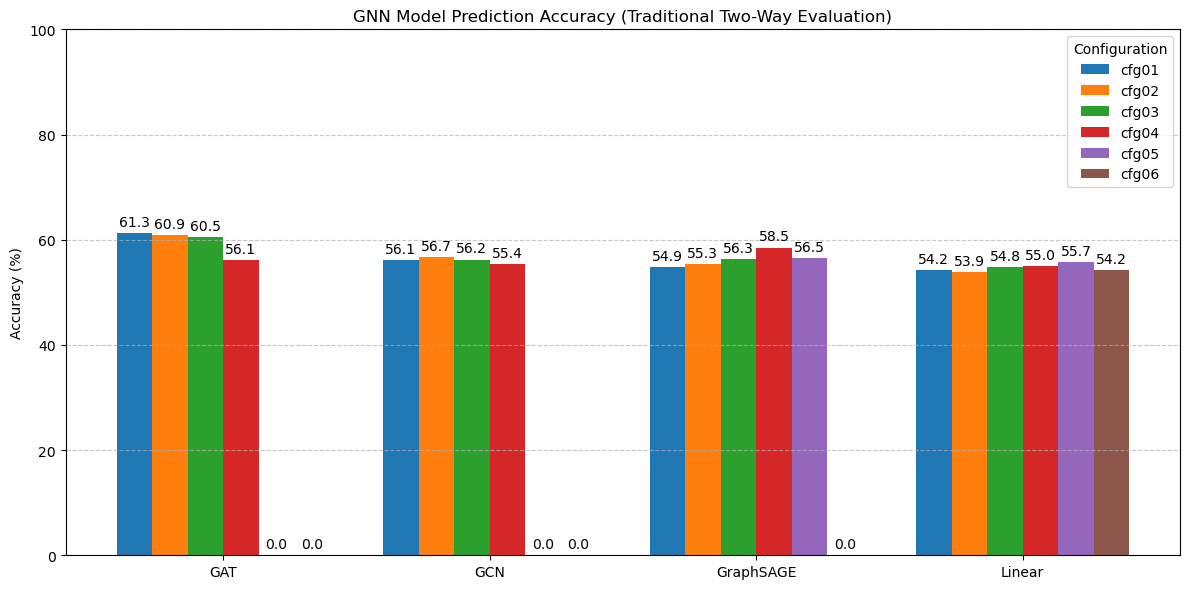

In [4]:
plot_gnn_results(traditional_eval, "GNN Model Prediction Accuracy (Traditional Two-Way Evaluation)")

In [5]:
def comparative_eval(filename):
    """
    Implements different eval technique comparing
    probability of one direction vs the other, rather than
    probability of each direction vs a threshold of 0.5.

    All labes are 1 in the prediction files.
    
    Args:
        filename: Path to the CSV file
        
    Returns:
        Percentage of rows where pred > reverse_pred
    """
    with open(filename, 'r') as f:
        reader = csv.DictReader(f)
        total = 0
        count = 0
        
        for row in reader:
            pred = float(row['pred'])
            reverse_pred = float(row['reverse_pred'])
            
            if (pred > reverse_pred):
                count += 1
            total += 1
    
    return round(count / total * 100, 2)

comparative_eval_results = {filename.split('/')[-1]: comparative_eval(filename) for filename in prediction_files}

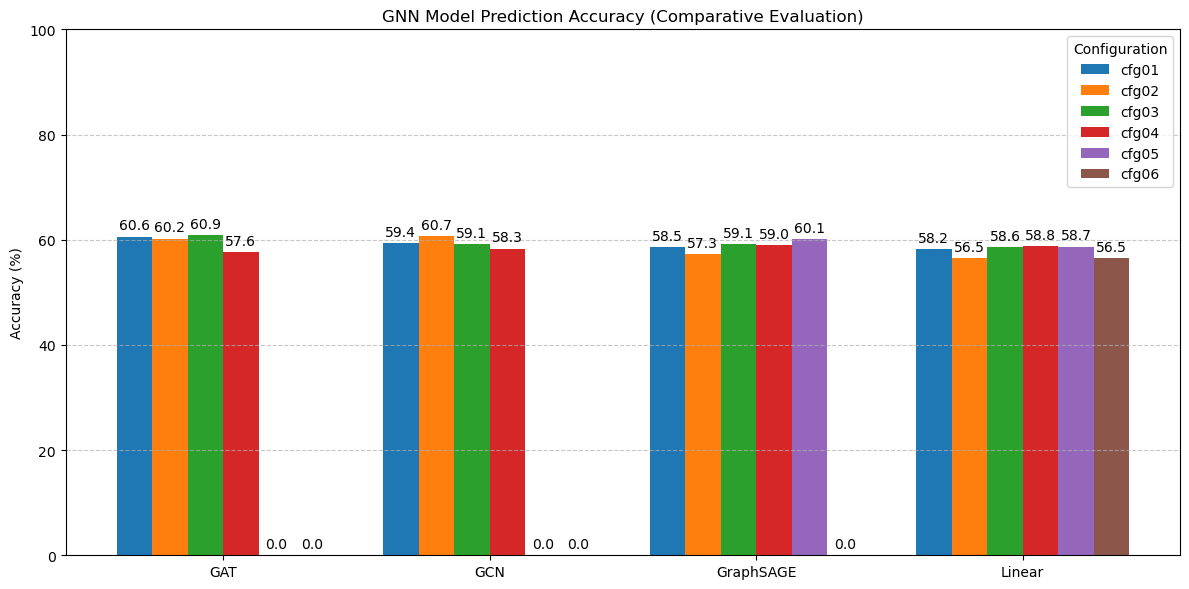

In [6]:
plot_gnn_results(comparative_eval_results, "GNN Model Prediction Accuracy (Comparative Evaluation)")

In [7]:
best_model_files = ["../predictions/GAT_cfg03.csv",
                    "../predictions/GCN_cfg02.csv",
                    "../predictions/GraphSAGE_cfg05.csv",
                    "../predictions/Linear_cfg04.csv"]

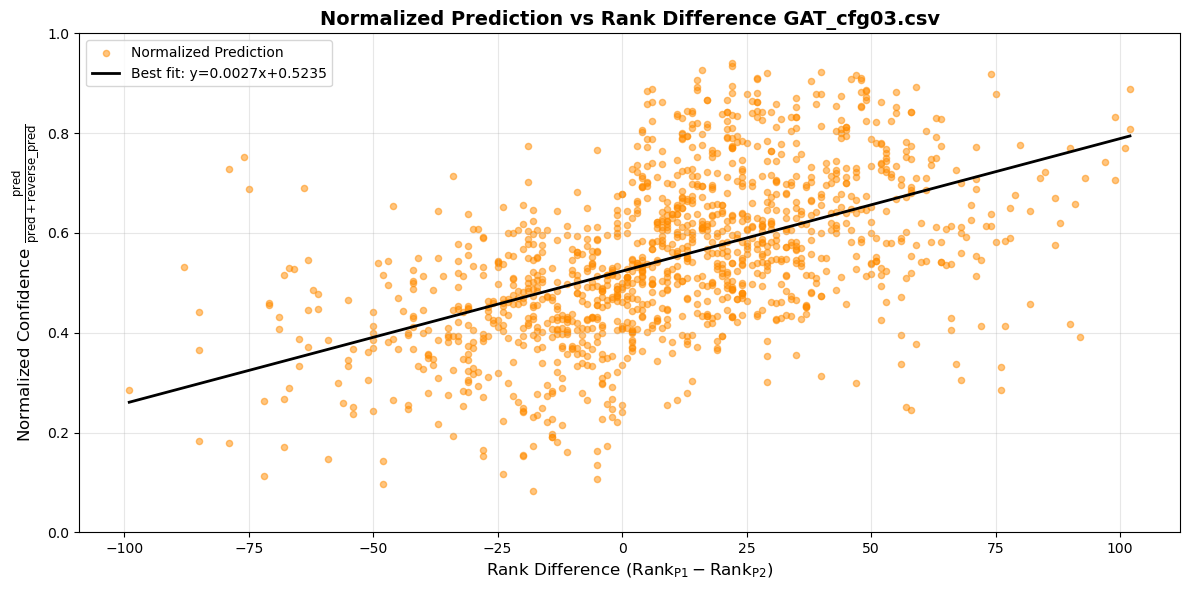

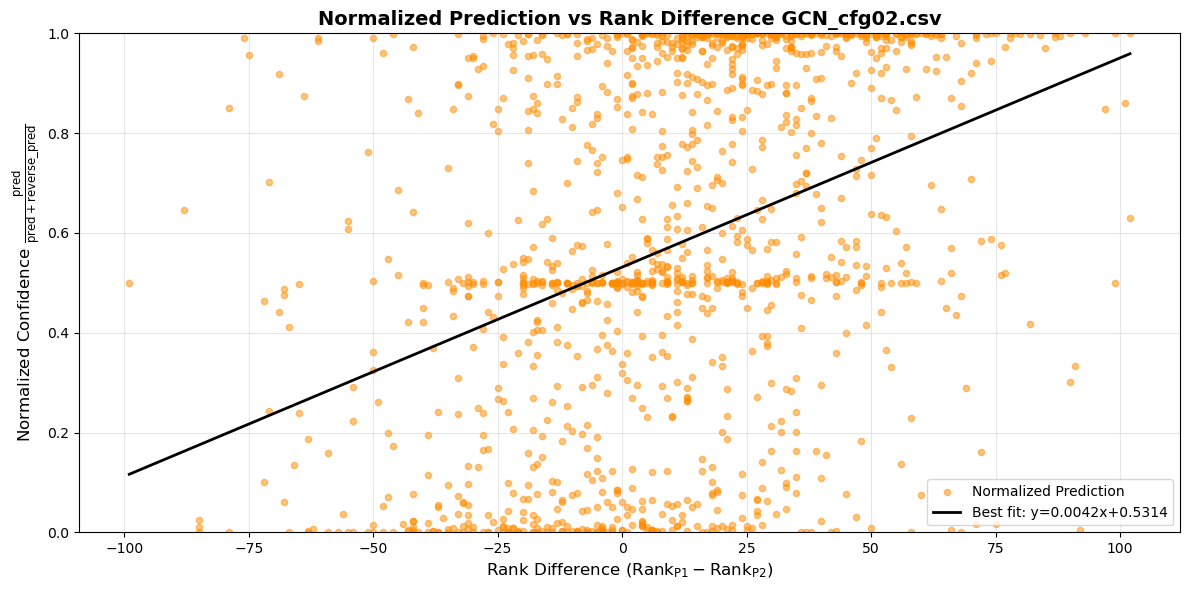

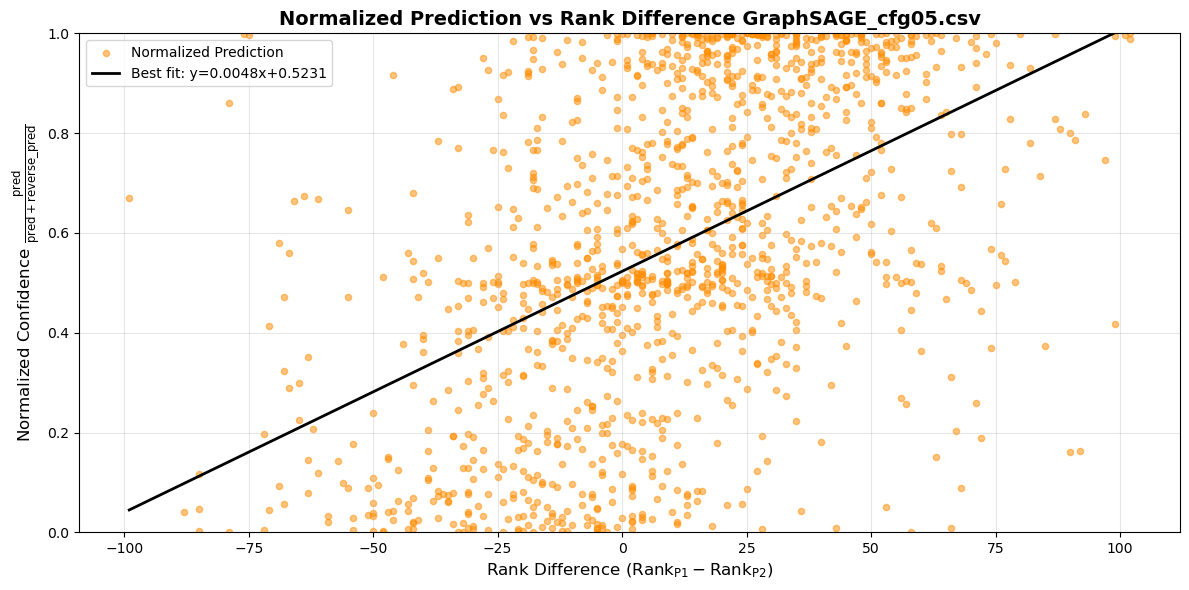

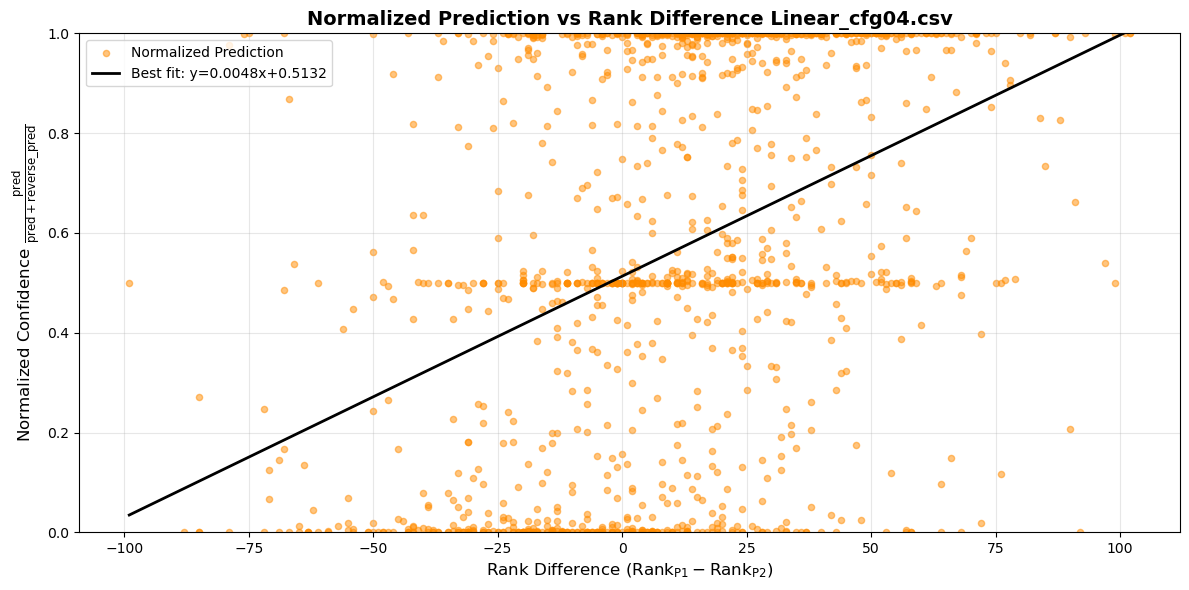

In [8]:
def plot_normalized_confidence_by_rank_difference(filename, players_filepath):
    """
    Plot scatter graph with a single line of best fit.
    
    - X-axis: p1_rank - p2_rank
    - Y-axis: Normalized confidence = pred / (pred + reverse_pred)
    
    Args:
        filename: Path to predictions CSV
        players_filepath: Path to players CSV
    """
    # Load data
    preds = pd.read_csv(filename)
    players = pd.read_csv(players_filepath)
    
    # Create a dictionary for quick rank lookup
    rank_dict = dict(zip(players['player_id'], players['current_rank']))
    
    # Get ranks for p1 and p2
    preds['p1_rank'] = preds['p1_id'].map(rank_dict)
    preds['p2_rank'] = preds['p2_id'].map(rank_dict)
    
    # Calculate rank differences
    preds['rank_diff'] = preds['p2_rank'] - preds['p1_rank']
    
    # Remove rows with missing ranks
    preds = preds.dropna(subset=['p1_rank', 'p2_rank'])
    
    # --- Data Normalization (Y-axis calculation) ---
    
    # Calculate the denominator (sum of confidence)
    preds['conf_sum'] = preds['pred'] + preds['reverse_pred']
    
    # Handle division by zero: if conf_sum is 0, the normalized value is undefined.
    # We will set the normalized confidence to NaN for these rows to exclude them from the plot.
    # Otherwise, calculate the normalized confidence.
    preds['normalized_confidence'] = np.where(
        preds['conf_sum'] == 0, 
        np.nan, 
        preds['pred'] / preds['conf_sum']
    )
    
    # Remove rows where normalized confidence couldn't be calculated (conf_sum = 0)
    final_data = preds.dropna(subset=['normalized_confidence'])

    # --- Plotting ---
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define X and Y for plotting
    X = final_data['rank_diff']
    Y = final_data['normalized_confidence']
    
    # Plot unified scatter graph
    ax.scatter(X, Y, 
               alpha=0.5, label='Normalized Prediction', 
               color='darkorange', s=20)
    
    # Calculate and plot the single line of best fit (Linear Regression)
    z = np.polyfit(X, Y, 1)
    p = np.poly1d(z)
    
    # Create line for the full range of X values
    x_line = np.linspace(X.min(), X.max(), 100)
    
    ax.plot(x_line, p(x_line), 'k-', linewidth=2, 
            label=f'Best fit: y={z[0]:.4f}x+{z[1]:.4f}')
    
    # --- Formatting ---
    ax.set_xlabel(r'Rank Difference ($\text{Rank}_{\text{P1}} - \text{Rank}_{\text{P2}}$)', fontsize=12)
    ax.set_ylabel(r'Normalized Confidence $\frac{\text{pred}}{\text{pred} + \text{reverse\_pred}}$', fontsize=12)
    ax.set_title(f'Normalized Prediction vs Rank Difference {filename.split("/")[-1]}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set Y-axis limits to 0 and 1, as the normalized confidence is a probability/ratio
    ax.set_ylim(0, 1) 
    
    plt.tight_layout()
    return fig

for filepath in best_model_files:
    fig = plot_normalized_confidence_by_rank_difference(filepath, PLAYERS)
    plt.show()

In [9]:
def plot_segmented_confidence_and_accuracy(predictions_filename, plot_title, segment_dict):
    """
    Displays a box plot for the normalized prediction confidences across player segments,
    and adds a line for the accuracy (%) for each segment.

    Args:
        predictions_filename (str): Path to predictions CSV.
        plot_title (str): Title for the box plot.
        segment_dict (dict): Dictionary mapping segment_label (str) to a set of player_ids (set).
    """
    
    # Load predictions data
    preds = pd.read_csv(predictions_filename)

    # --- 1. Confidence Normalization ---
    
    # Calculate the denominator (sum of confidence)
    preds['conf_sum'] = preds['pred'] + preds['reverse_pred']
    
    # Calculate the normalized confidence Y = pred / (pred + reverse_pred)
    # Use np.where to handle division by zero (set to NaN)
    preds['normalized_confidence'] = np.where(
        preds['conf_sum'] == 0, 
        np.nan, 
        preds['pred'] / preds['conf_sum']
    )
    
    # Drop rows where normalized confidence couldn't be calculated (conf_sum = 0)
    preds = preds.dropna(subset=['normalized_confidence'])

    # --- 2. Segmentation and Data Preparation ---

    segment_data = {}
    accuracy_data = {}
    segment_labels = list(segment_dict.keys())

    # Create a set of all segmented IDs for quick lookup
    all_segmented_ids = set().union(*segment_dict.values())
    
    # Identify which segment(s) each match belongs to
    def get_match_segments(p1_id, p2_id):
        match_segments = set()
        for label, id_set in segment_dict.items():
            if p1_id in id_set or p2_id in id_set:
                match_segments.add(label)
        return match_segments

    # Apply the segmentation function to create a list of applicable segments for each match
    # We only care about matches where at least one player is in any segment
    preds['segments'] = preds.apply(lambda row: get_match_segments(row['p1_id'], row['p2_id']), axis=1)
    
    # Filter to only matches that belong to at least one segment
    segmented_matches = preds[preds['segments'].apply(bool)].copy()

    # Process data for plotting and accuracy calculation
    for label in segment_labels:
        # Get all matches where the segment label is in the 'segments' set
        current_segment_df = segmented_matches[segmented_matches['segments'].apply(lambda s: label in s)]
        
        # 1. Confidence Data (for Box Plot)
        # Collect the normalized confidence values
        segment_data[label] = current_segment_df['normalized_confidence'].tolist()
        
        # 2. Accuracy Data (for Line Plot)
        # Accuracy is defined as: number of times pred > reverse_pred
        # The number of correct predictions (P1 wins) is where pred > reverse_pred
        correct_predictions = (current_segment_df['pred'] > current_segment_df['reverse_pred']).sum()
        total_predictions = len(current_segment_df)
        
        if total_predictions > 0:
            accuracy = (correct_predictions / total_predictions) * 100
        else:
            accuracy = 0
            
        accuracy_data[label] = accuracy

    # --- 3. Plotting (Box Plot and Line Plot) ---
    
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Box Plot (Normalized Confidence Distribution) ---
    box_data = [segment_data[label] for label in segment_labels]
    
    # Create the box plot on ax1 (left y-axis)
    bp = ax1.boxplot(box_data, positions=range(len(segment_labels)), 
                      labels=segment_labels, patch_artist=True, 
                      showfliers=False, medianprops={'color': 'black'})
    
    # Optional: Fill boxes with colors
    colors = plt.cm.get_cmap('Pastel2', len(segment_labels))
    for patch, color in zip(bp['boxes'], colors(range(len(segment_labels)))):
        patch.set_facecolor(color)

    ax1.set_xlabel('Player Segment', fontsize=12)
    ax1.set_ylabel('Normalized Confidence Distribution', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, 1) # Confidence is a ratio between 0 and 1
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Line Plot (Accuracy) ---
    
    # Create a secondary y-axis for the accuracy line
    ax2 = ax1.twinx()
    
    acc_values = [accuracy_data[label] for label in segment_labels]
    
    # Plot the accuracy line on ax2 (right y-axis)
    line, = ax2.plot(range(len(segment_labels)), acc_values, 
                     color='tab:red', marker='o', linestyle='-', linewidth=2, 
                     label='Accuracy (%)')
    
    # Add accuracy labels above the points
    for i, acc in enumerate(acc_values):
        ax2.text(i, acc + 1.5, f'{acc:.1f}%', 
                 ha='center', color='tab:red', fontweight='bold')
    
    ax2.set_ylabel('Accuracy (%)', color='tab:red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_ylim(0, 100) # Accuracy is a percentage
    
    # Final Formatting
    ax1.set_title(plot_title, fontsize=14, fontweight='bold')
    
    # Manually create a combined legend
    ax1.legend([bp['boxes'][0], line], ['Confidence Distribution', 'Accuracy (%)'], loc='upper left')
    
    plt.tight_layout()
    plt.show()
    return fig

--- Generated Segmentation Dictionary for Height (cm) ---
'170-176': 8 players
'176-181': 22 players
'181-186': 56 players
'186-192': 32 players
'192-198': 25 players
'198-203': 7 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


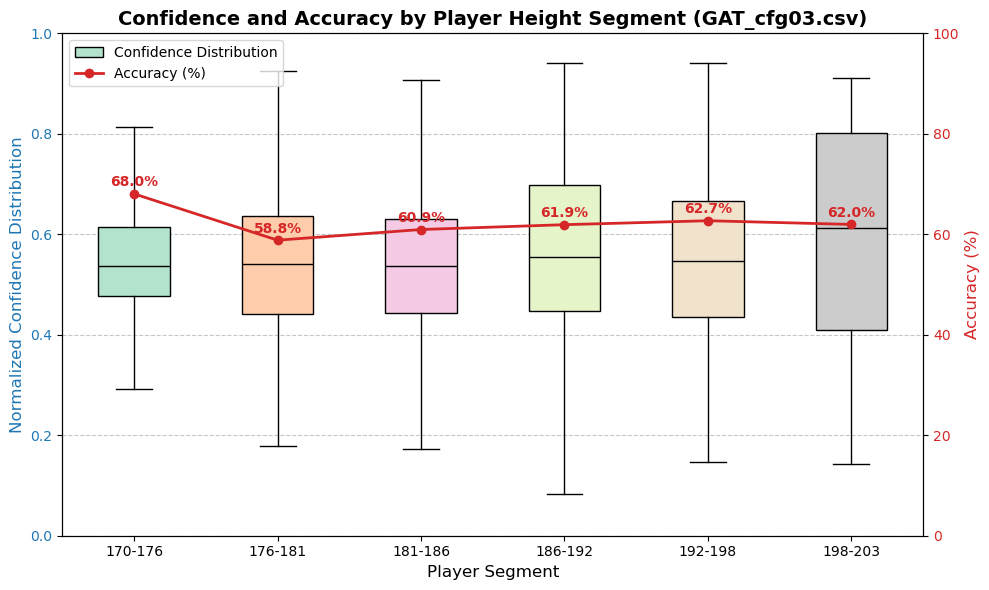

--- Generated Segmentation Dictionary for Height (cm) ---
'170-176': 8 players
'176-181': 22 players
'181-186': 56 players
'186-192': 32 players
'192-198': 25 players
'198-203': 7 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


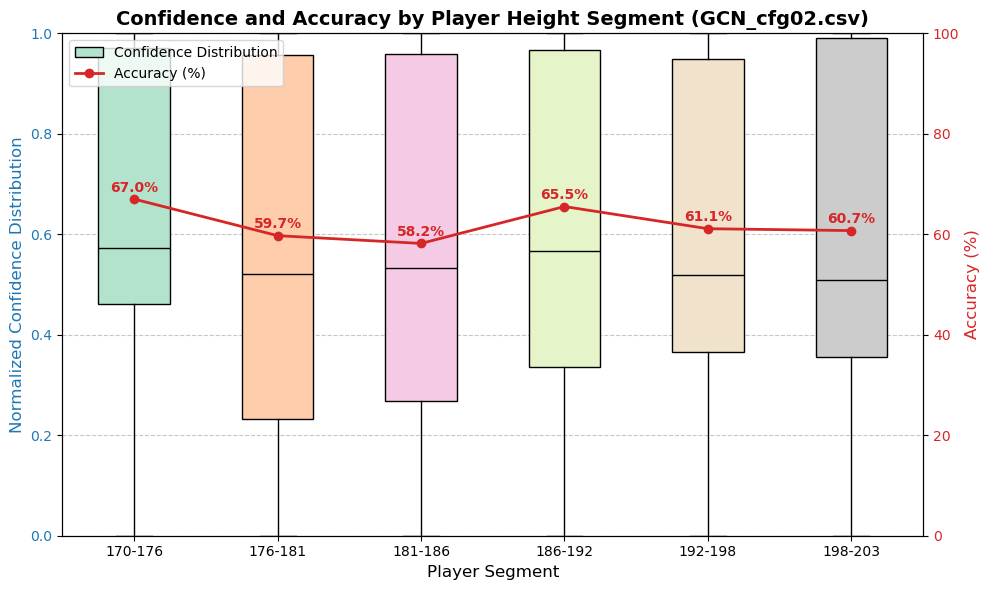

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),


--- Generated Segmentation Dictionary for Height (cm) ---
'170-176': 8 players
'176-181': 22 players
'181-186': 56 players
'186-192': 32 players
'192-198': 25 players
'198-203': 7 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


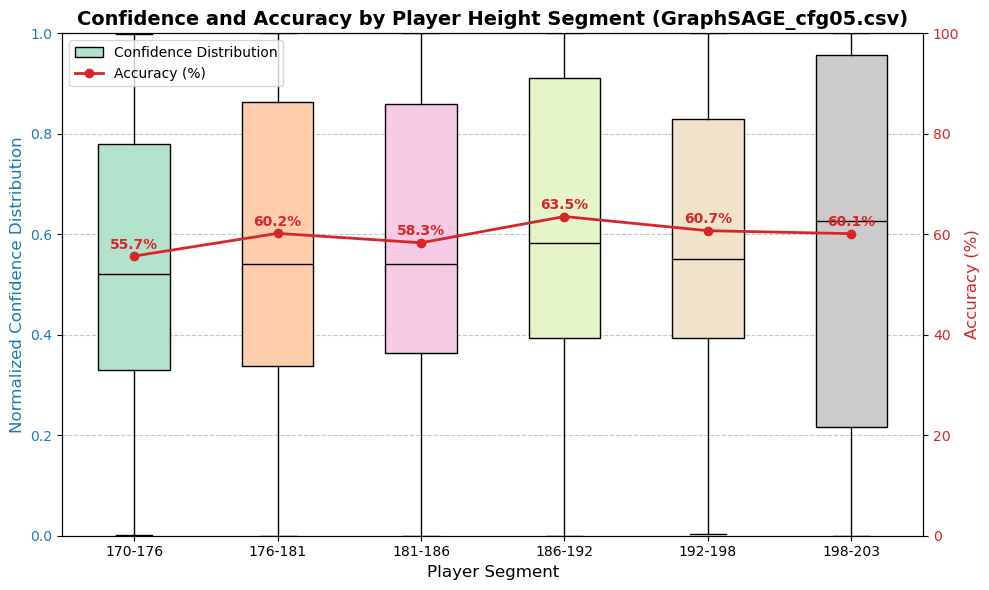

--- Generated Segmentation Dictionary for Height (cm) ---
'170-176': 8 players
'176-181': 22 players
'181-186': 56 players
'186-192': 32 players
'192-198': 25 players
'198-203': 7 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


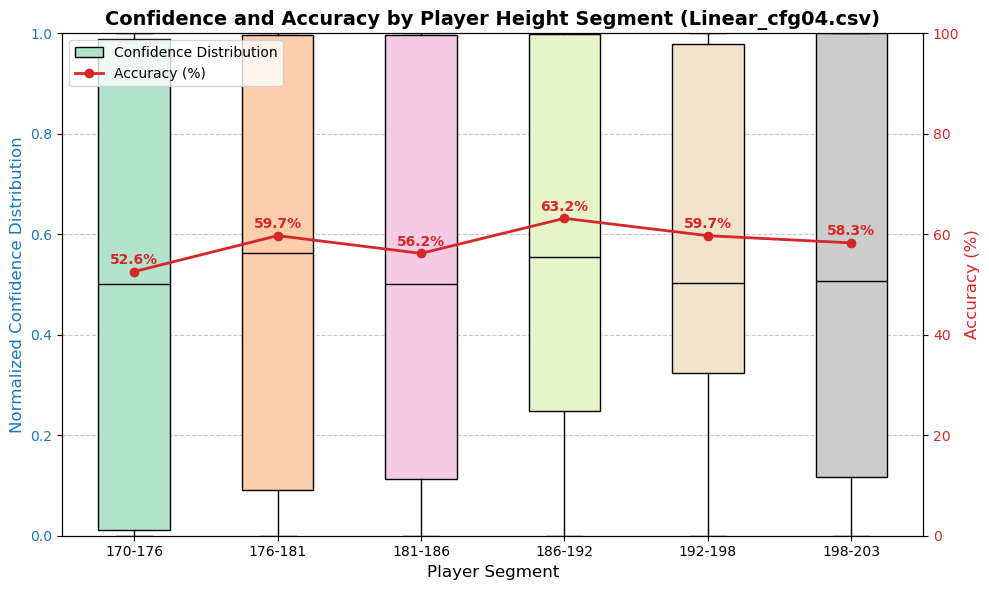

--- Generated Segmentation Dictionary for Age (Years) ---
'20-23': 20 players
'23-27': 38 players
'27-30': 53 players
'30-33': 22 players
'33-37': 7 players
'37-40': 10 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


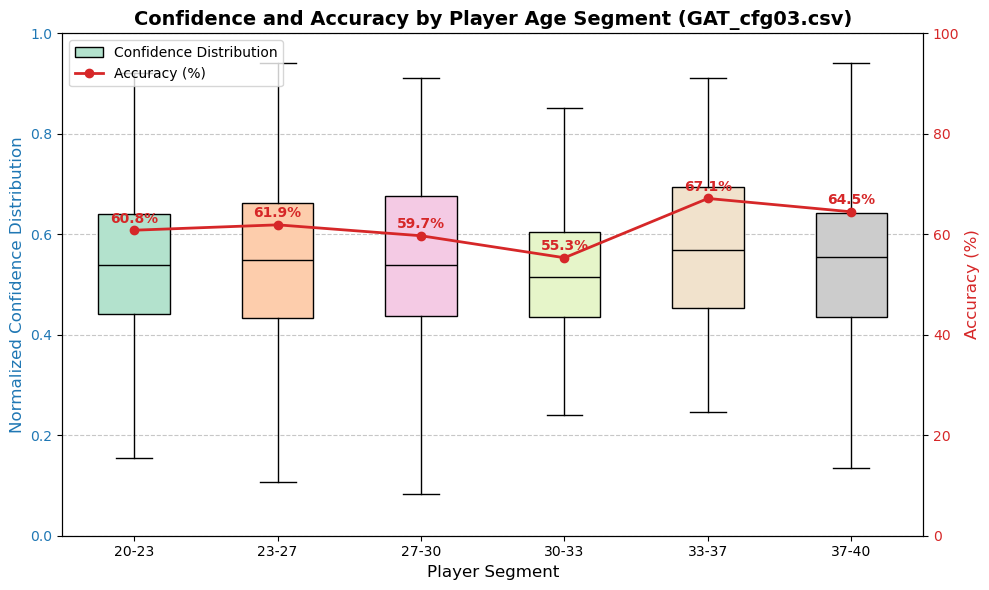

--- Generated Segmentation Dictionary for Age (Years) ---
'20-23': 20 players
'23-27': 38 players
'27-30': 53 players
'30-33': 22 players
'33-37': 7 players
'37-40': 10 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


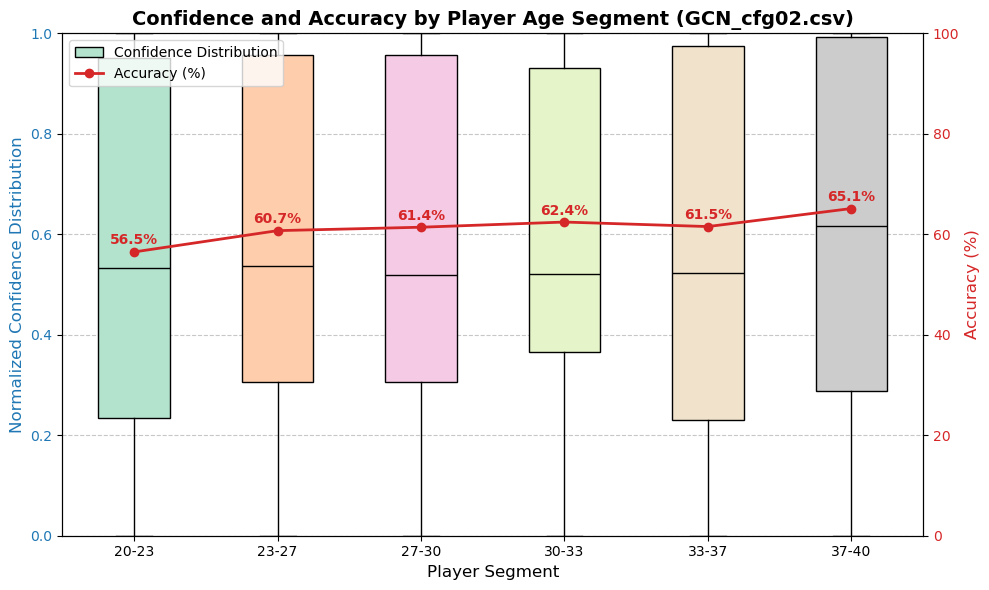

--- Generated Segmentation Dictionary for Age (Years) ---
'20-23': 20 players
'23-27': 38 players
'27-30': 53 players
'30-33': 22 players
'33-37': 7 players
'37-40': 10 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


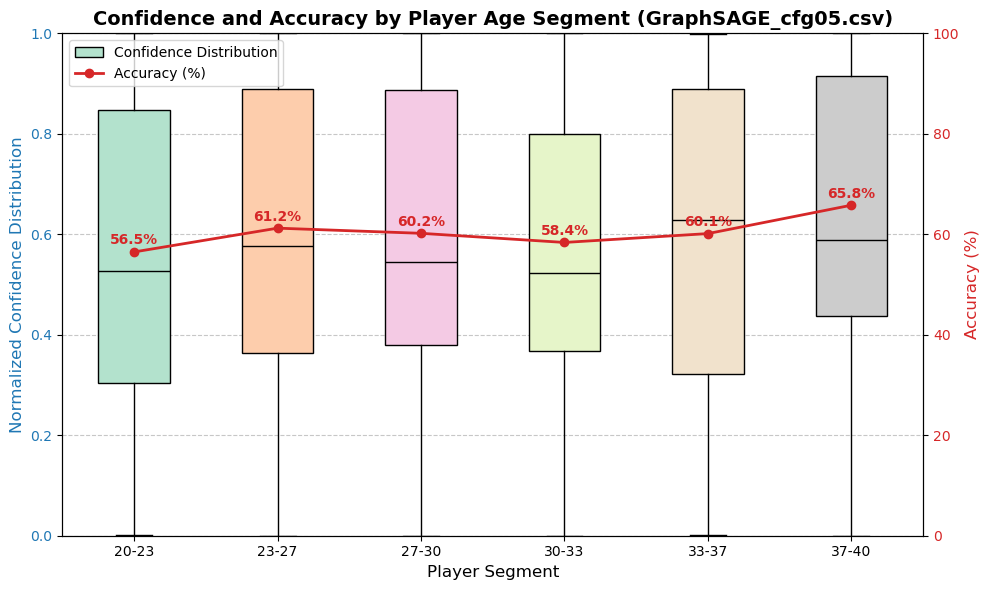

--- Generated Segmentation Dictionary for Age (Years) ---
'20-23': 20 players
'23-27': 38 players
'27-30': 53 players
'30-33': 22 players
'33-37': 7 players
'37-40': 10 players
Total players segmented: 150
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


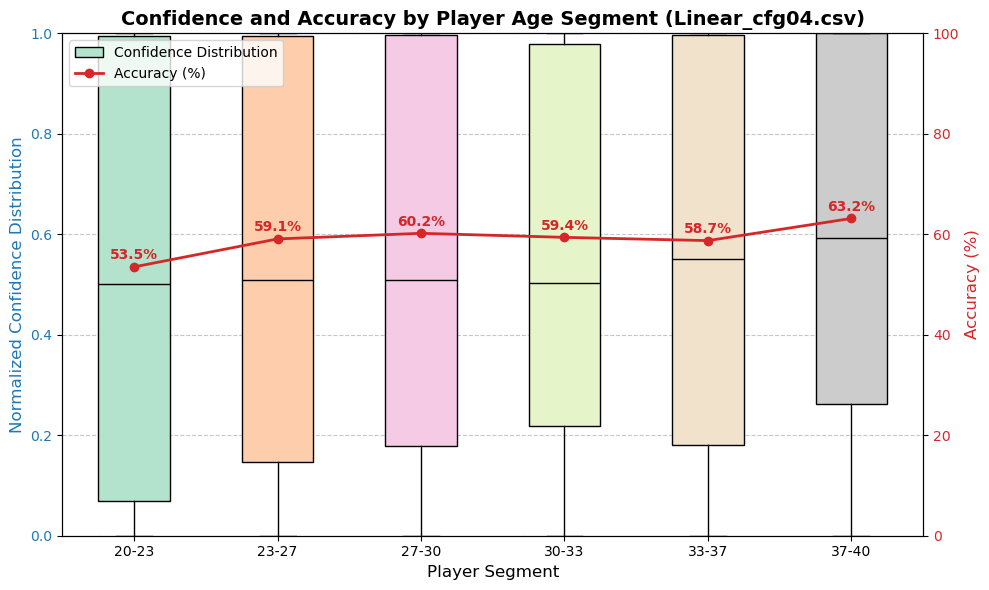

In [10]:
import datetime as dt

def segment_players_and_plot(predictions_filename, feature, num_segments=6):
    """
    Segments players based on 'height' or 'dob' into equal bins, creates the 
    segment dictionary, and calls the plotting function.

    Args:
        predictions_filename (str): Path to predictions CSV.
        feature (str): The feature to segment on ('height' or 'dob').
        num_segments (int): The number of segments (bins) to create.
    """
    # Load player data
    try:
        players = pd.read_csv(PLAYERS)
    except FileNotFoundError:
        print(f"Error: Player file not found at {PLAYERS}")
        return

    df = players.copy()
    feature_name = feature.lower()

    if feature_name == 'dob':
        # --- Calculate Age for DOB feature ---
        
        # 1. Convert the float (YYYYMMDD.0) to an integer string (YYYYMMDD)
        # Handle non-numeric or NaN values by setting them to NaN
        df['dob_str'] = df['dob'].apply(
            lambda x: str(int(x)) if pd.notna(x) else np.nan
        )
        
        # 2. Convert the YYYYMMDD string to a datetime object
        df['birth_date'] = pd.to_datetime(df['dob_str'], format='%Y%m%d', errors='coerce')
        
        today = dt.datetime.now().date()
        
        # Calculate age in years
        def calculate_age(born):
            if pd.isna(born):
                return np.nan
            # Ensure 'born' is a date object for comparison
            born_date = born.date() if isinstance(born, dt.datetime) else born
            return today.year - born_date.year - ((today.month, today.day) < (born_date.month, born_date.day))

        df['age'] = df['birth_date'].apply(calculate_age)
        data_series = df['age'].dropna()
        plot_feature_label = 'Age (Years)'
        plot_title = f"Confidence and Accuracy by Player Age Segment ({predictions_filename.split('/')[-1]})"

    elif feature_name == 'height':
        # --- Use Height feature directly ---
        data_series = df['height'].dropna()
        plot_feature_label = 'Height (cm)'
        plot_title = f"Confidence and Accuracy by Player Height Segment ({predictions_filename.split('/')[-1]})"
    
    else:
        print("Error: Feature must be 'height' or 'dob'.")
        return

    if data_series.empty:
        print(f"Error: No valid data found for feature '{feature}'.")
        return

    # --- 1. Create Segments (Equal-Width Binning) ---
    
    min_val = data_series.min()
    max_val = data_series.max()
    
    # Calculate bin edges
    bins = np.linspace(min_val, max_val, num_segments + 1)
    
    # Assign each player to a bin index
    df['bin'] = pd.cut(df[feature_name if feature_name == 'height' else 'age'], 
                       bins=bins, 
                       labels=False, 
                       include_lowest=True, 
                       right=True)

    # --- 2. Build the Segment Dictionary ---
    segment_dict = {}
    
    for i in range(num_segments):
        # Find players in the current bin
        bin_players = df[df['bin'] == i]
        
        # Create the label for the bin (e.g., "170-180")
        lower_bound = bins[i]
        upper_bound = bins[i+1]
        
        # Format the label to be clean (usually integers for age/height bins)
        label = f"{int(round(lower_bound))}-{int(round(upper_bound))}"
        
        # Store the set of player IDs for this segment
        segment_dict[label] = set(bin_players['player_id'].tolist())

    # Print the resulting segmentation dictionary for inspection
    print(f"--- Generated Segmentation Dictionary for {plot_feature_label} ---")
    total_players = 0
    for label, id_set in segment_dict.items():
        count = len(id_set)
        print(f"'{label}': {count} players")
        total_players += count
    print(f"Total players segmented: {total_players}")
    print("---------------------------------------")

    # --- 3. Call the Plotting Function ---
    # Ensure PLAYERS is passed as players_filepath, not the dataframe
    plot_segmented_confidence_and_accuracy(
        predictions_filename=predictions_filename,
        plot_title=plot_title,
        segment_dict=segment_dict
    )

for filepath in best_model_files:
    segment_players_and_plot(filepath, feature='height', num_segments=6)
for filepath in best_model_files:
    segment_players_and_plot(filepath, feature='dob', num_segments=6)

--- Generated Segmentation Dictionary for Handedness ---
'Right-handed': 130 players
'Left-handed': 20 players
Total players segmented: 150
Players ignored (hand != 0 or 1): 0
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


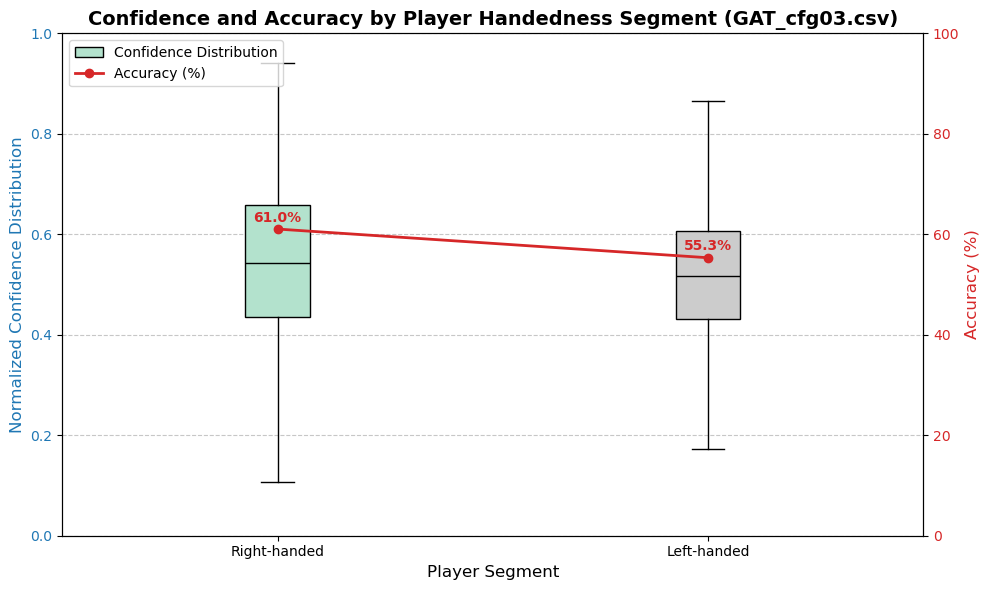

--- Generated Segmentation Dictionary for Handedness ---
'Right-handed': 130 players
'Left-handed': 20 players
Total players segmented: 150
Players ignored (hand != 0 or 1): 0
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


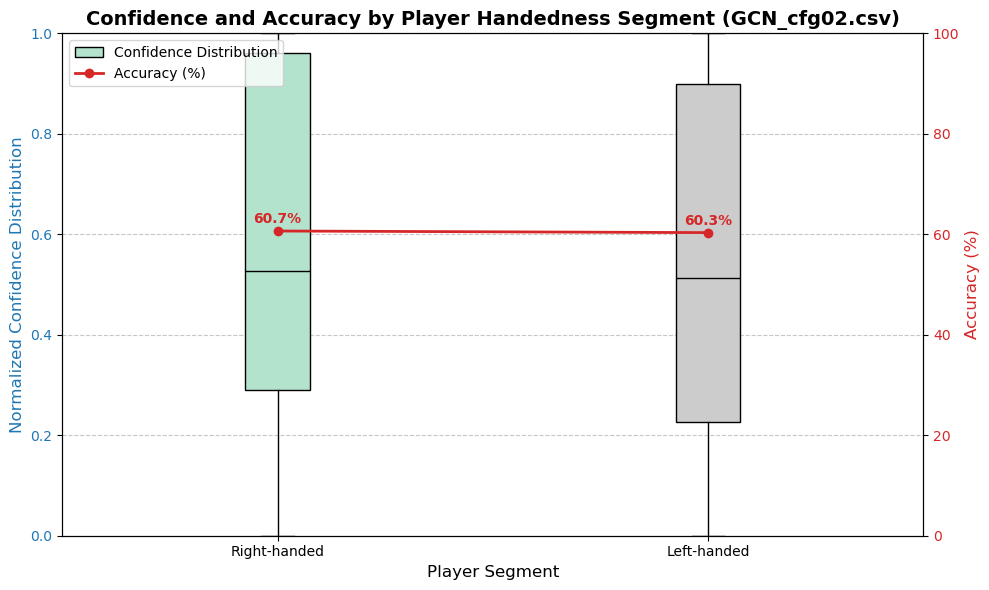

--- Generated Segmentation Dictionary for Handedness ---
'Right-handed': 130 players
'Left-handed': 20 players
Total players segmented: 150
Players ignored (hand != 0 or 1): 0
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


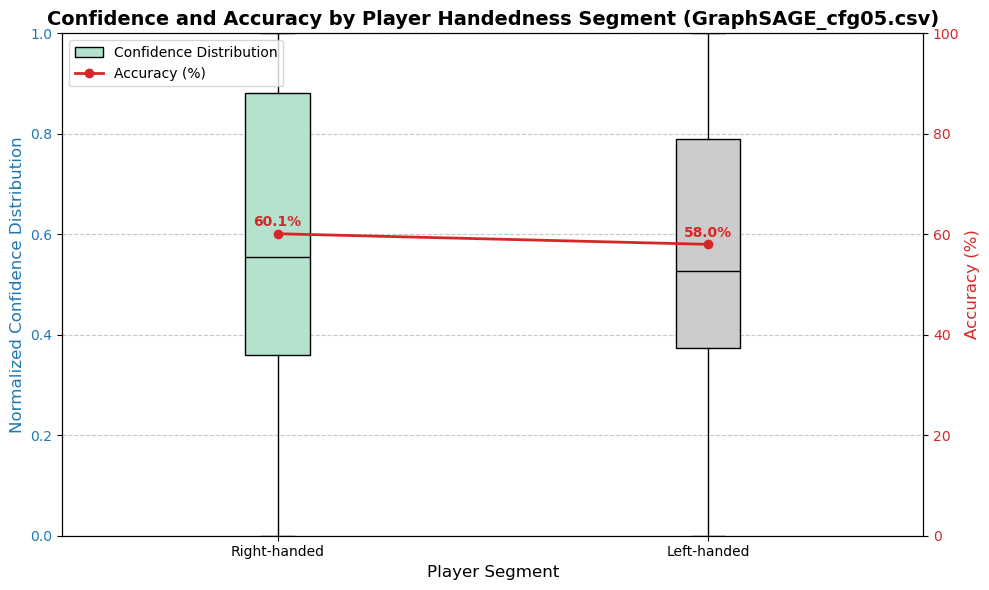

--- Generated Segmentation Dictionary for Handedness ---
'Right-handed': 130 players
'Left-handed': 20 players
Total players segmented: 150
Players ignored (hand != 0 or 1): 0
---------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


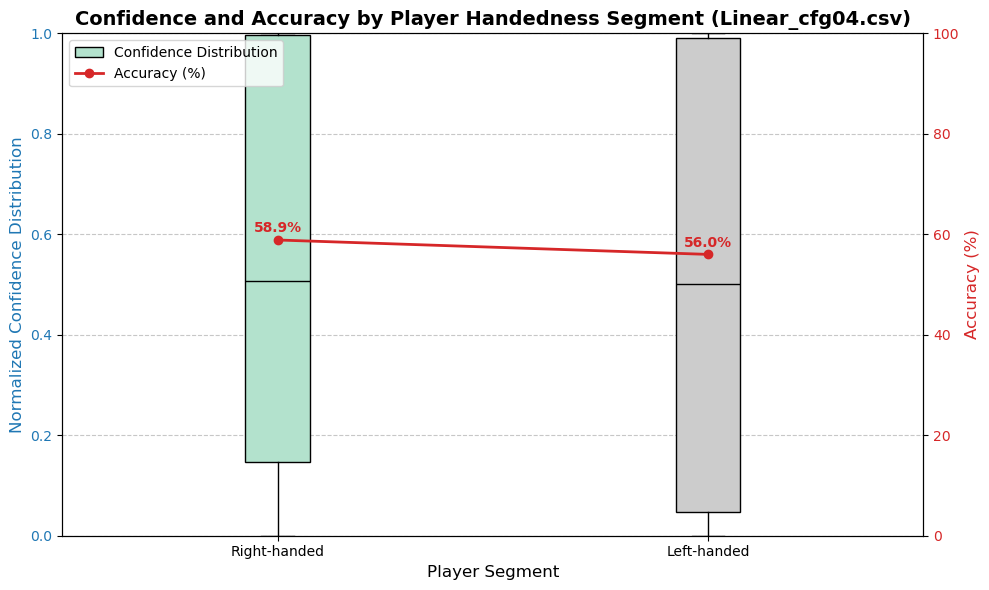

In [11]:
def segment_players_by_hand_and_plot(predictions_filename):
    """
    Segments players into Right-handed (0) and Left-handed (1) groups,
    creates the segment dictionary, and calls the plotting function.

    Args:
        predictions_filename (str): Path to predictions CSV.
    """
    # Load player data
    try:
        players = pd.read_csv(PLAYERS)
    except FileNotFoundError:
        print(f"Error: Player file not found at {PLAYERS}")
        return

    df = players.copy()
    
    # --- 1. Filter and Prepare Data ---
    
    # Ensure 'hand' is treated as a numeric type for comparison, 
    # but only keep values that are exactly 0 or 1.
    valid_hands = df['hand'].isin([0, 1])
    df_valid = df[valid_hands].copy()
    
    # --- 2. Build the Segment Dictionary ---
    segment_dict = {}
    
    # Segment 1: Right-handed (hand == 0)
    right_handed_players = df_valid[df_valid['hand'] == 0]['player_id'].tolist()
    segment_dict['Right-handed'] = set(right_handed_players)
    
    # Segment 2: Left-handed (hand == 1)
    left_handed_players = df_valid[df_valid['hand'] == 1]['player_id'].tolist()
    segment_dict['Left-handed'] = set(left_handed_players)

    # --- 3. Contextual Information ---
    
    plot_title = f"Confidence and Accuracy by Player Handedness Segment ({predictions_filename.split('/')[-1]})"

    # Print the resulting segmentation dictionary for inspection
    print("--- Generated Segmentation Dictionary for Handedness ---")
    total_players = 0
    for label, id_set in segment_dict.items():
        count = len(id_set)
        print(f"'{label}': {count} players")
        total_players += count
    print(f"Total players segmented: {total_players}")
    print(f"Players ignored (hand != 0 or 1): {len(df) - len(df_valid)}")
    print("---------------------------------------")

    # --- 4. Call the Plotting Function ---
    plot_segmented_confidence_and_accuracy(
        predictions_filename=predictions_filename,
        plot_title=plot_title,
        segment_dict=segment_dict
    )

for filepath in best_model_files:
    segment_players_by_hand_and_plot(filepath)

--- Generated Segmentation Dictionary for Top 10 Countries ---
'FRA': 18 players
'USA': 14 players
'AUS': 11 players
'ARG': 11 players
'ITA': 10 players
'ESP': 8 players
'GBR': 7 players
'RUS': 6 players
'GER': 6 players
'SRB': 5 players
Total countries segmented: 10
Total players segmented: 96
Players ignored (outside top 10 or missing map): 54
----------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


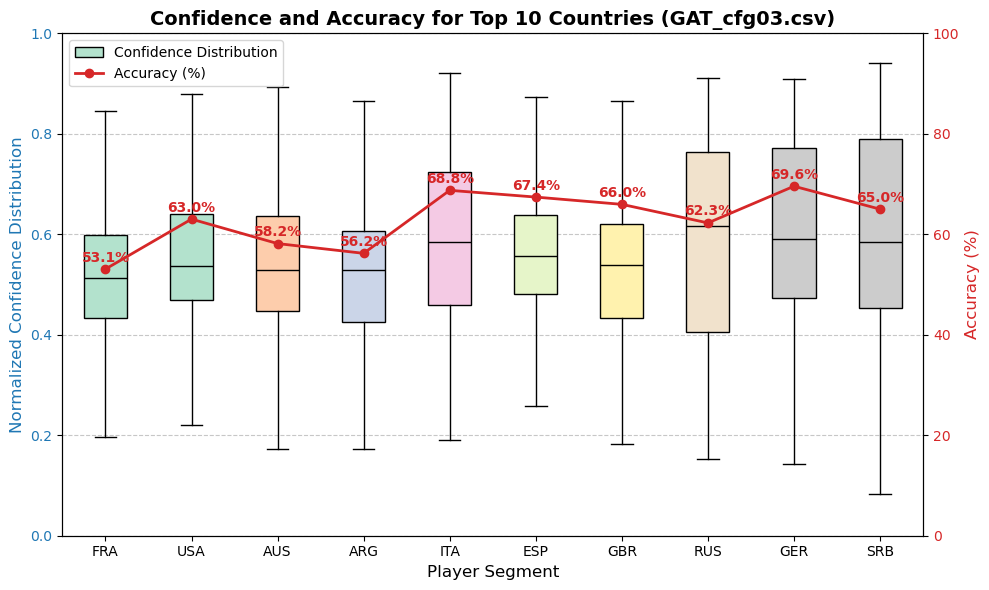

--- Generated Segmentation Dictionary for Top 10 Countries ---
'FRA': 18 players
'USA': 14 players
'AUS': 11 players
'ARG': 11 players
'ITA': 10 players
'ESP': 8 players
'GBR': 7 players
'RUS': 6 players
'GER': 6 players
'SRB': 5 players
Total countries segmented: 10
Total players segmented: 96
Players ignored (outside top 10 or missing map): 54
----------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


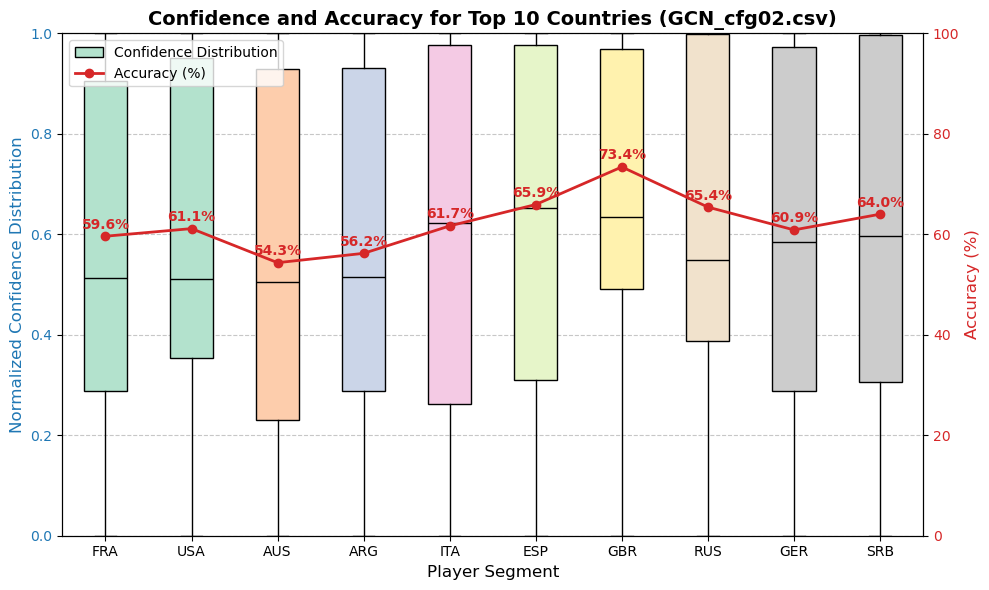

--- Generated Segmentation Dictionary for Top 10 Countries ---
'FRA': 18 players
'USA': 14 players
'AUS': 11 players
'ARG': 11 players
'ITA': 10 players
'ESP': 8 players
'GBR': 7 players
'RUS': 6 players
'GER': 6 players
'SRB': 5 players
Total countries segmented: 10
Total players segmented: 96
Players ignored (outside top 10 or missing map): 54
----------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


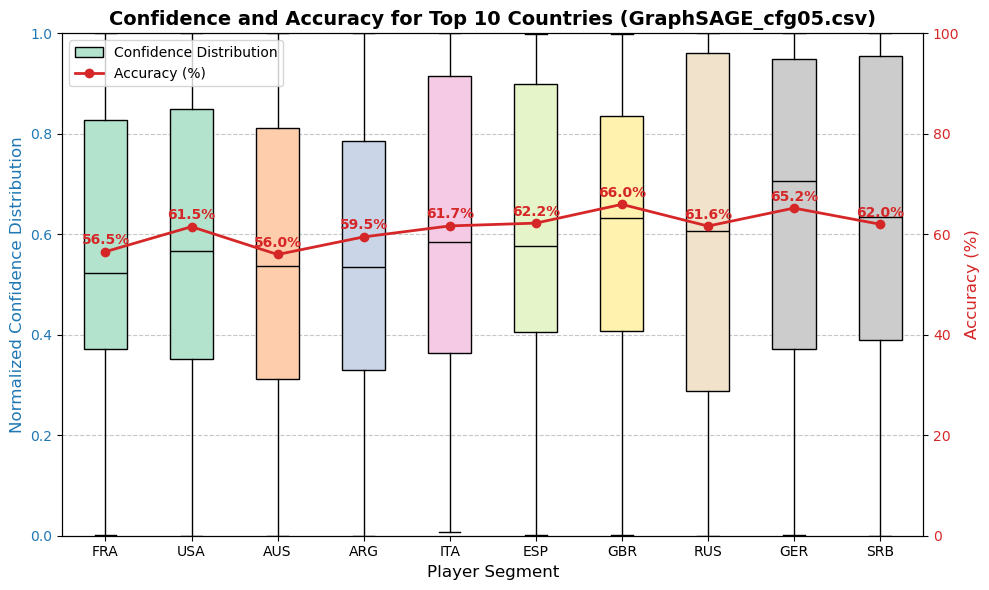

--- Generated Segmentation Dictionary for Top 10 Countries ---
'FRA': 18 players
'USA': 14 players
'AUS': 11 players
'ARG': 11 players
'ITA': 10 players
'ESP': 8 players
'GBR': 7 players
'RUS': 6 players
'GER': 6 players
'SRB': 5 players
Total countries segmented: 10
Total players segmented: 96
Players ignored (outside top 10 or missing map): 54
----------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


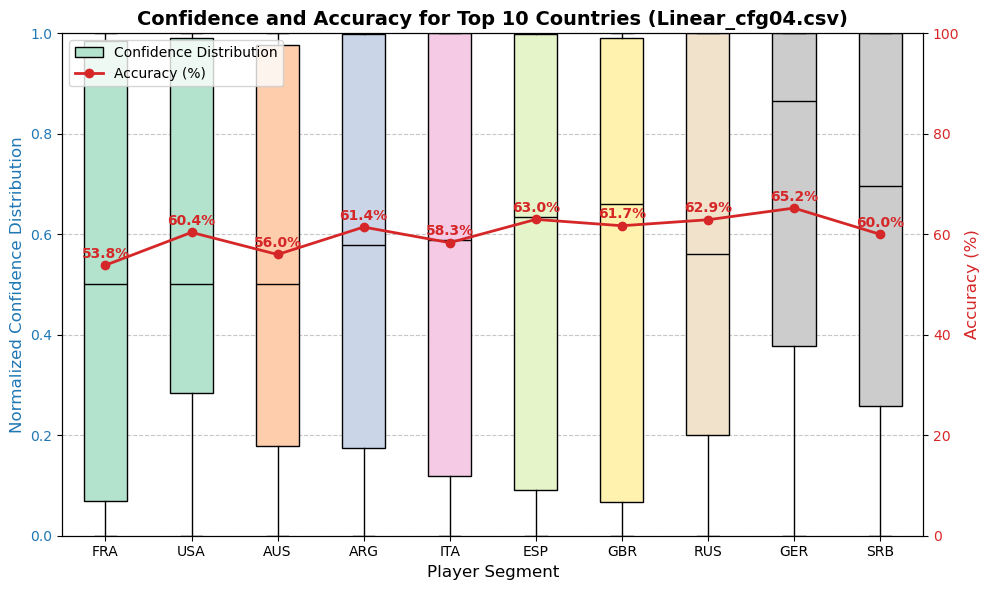

In [12]:
def segment_players_by_country_and_plot(predictions_filename):
    """
    Segments players based on 'country_num', filters to the top 15 countries 
    by player count, and calls the plotting function.

    Args:
        predictions_filename (str): Path to predictions CSV.
    """
    
    # Define the path to the mapping file relative to the assumed data location
    mapping_filepath = "../data/country_mapping.txt" 
    TOP_N_COUNTRIES = 10
    
    # --- 1. Load Country Mapping ---
    country_map = {}
    try:
        with open(mapping_filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    country_num = int(parts[0])
                    country_code = parts[1]
                    country_map[country_num] = country_code
        if not country_map:
            print(f"Error: Country mapping file at {mapping_filepath} is empty or invalid.")
            return
    except FileNotFoundError:
        print(f"Error: Country mapping file not found at {mapping_filepath}.")
        return
    except ValueError:
        print(f"Error: Invalid data format found in {mapping_filepath}. Expected 'int\\tstr'.")
        return


    # --- 2. Load Player Data ---
    try:
        players = pd.read_csv(PLAYERS)
    except FileNotFoundError:
        print(f"Error: Player file not found at {PLAYERS}")
        return

    df = players.copy()
    
    # --- 3. Filter Players and Calculate Counts ---
    
    # Only keep players whose country_num is known
    valid_countries_mask = df['country_num'].isin(country_map.keys())
    df_valid = df[valid_countries_mask].copy()
    
    # Get the count of players per country
    country_counts = df_valid['country_num'].value_counts()
    
    # Filter to the top N countries
    top_country_nums = country_counts.nlargest(TOP_N_COUNTRIES).index.tolist()
    
    # Filter the DataFrame to only include players from the top N countries
    df_top_countries = df_valid[df_valid['country_num'].isin(top_country_nums)]
    
    # --- 4. Build the Sorted Segment Dictionary ---
    segment_dict = {}
    
    # Group the filtered data by country_num and get player_ids as sets
    grouped_by_country = df_top_countries.groupby('country_num')['player_id'].apply(set).to_dict()

    # The final dictionary keys must be sorted by count (from largest to smallest)
    # We use a list of (count, country_num) tuples, sorted descending by count
    sorted_country_nums = country_counts.nlargest(TOP_N_COUNTRIES).index.tolist()

    for country_num in sorted_country_nums:
        # Get the descriptive code (e.g., 'SRB')
        country_code = country_map[country_num]
        
        # Get the set of player IDs
        player_ids = grouped_by_country[country_num]
        
        # Add to the dictionary in the correct order
        segment_dict[country_code] = player_ids

    # --- 5. Contextual Information ---
    
    plot_title = f"Confidence and Accuracy for Top {TOP_N_COUNTRIES} Countries ({predictions_filename.split('/')[-1]})"
    
    # Print the resulting segmentation dictionary for inspection
    print(f"--- Generated Segmentation Dictionary for Top {TOP_N_COUNTRIES} Countries ---")
    total_players = 0
    for label, id_set in segment_dict.items():
        count = len(id_set)
        print(f"'{label}': {count} players")
        total_players += count
    print(f"Total countries segmented: {len(segment_dict)}")
    print(f"Total players segmented: {total_players}")
    print(f"Players ignored (outside top {TOP_N_COUNTRIES} or missing map): {len(df) - total_players}")
    print("----------------------------------------------------------")

    # --- 6. Call the Plotting Function ---
    plot_segmented_confidence_and_accuracy(
        predictions_filename=predictions_filename,
        plot_title=plot_title,
        segment_dict=segment_dict
    )

for filepath in best_model_files:
    segment_players_by_country_and_plot(filepath)

--- Generated Segmentation Dictionary for Appearance Count ---
'4-56': 44 players
'56-109': 38 players
'109-161': 26 players
'161-213': 19 players
'213-265': 14 players
'265-318': 5 players
'318-370': 4 players
Total segments created: 7
Total players segmented: 150
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


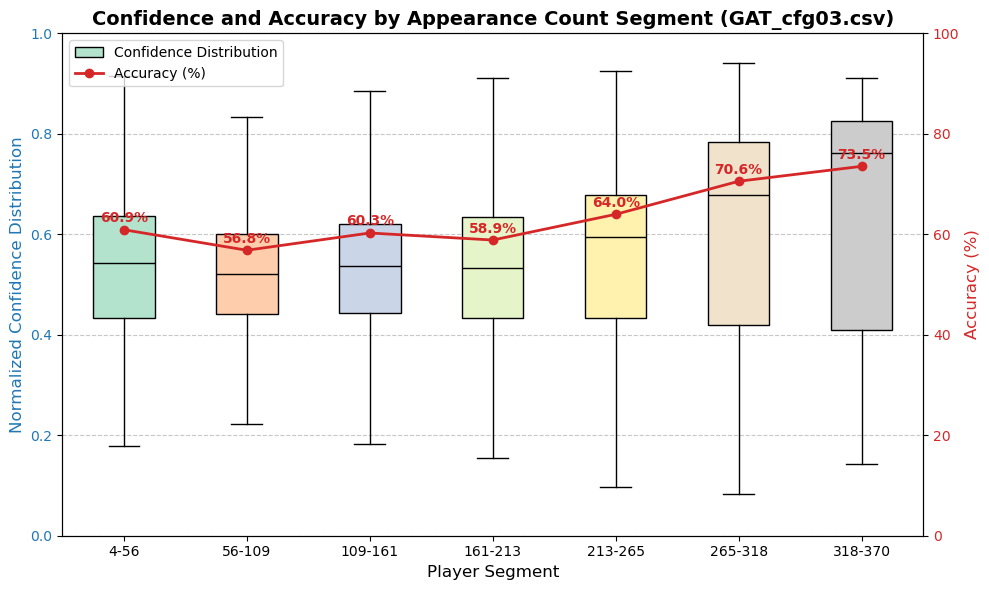

--- Generated Segmentation Dictionary for Appearance Count ---
'4-56': 44 players
'56-109': 38 players
'109-161': 26 players
'161-213': 19 players
'213-265': 14 players
'265-318': 5 players
'318-370': 4 players
Total segments created: 7
Total players segmented: 150
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


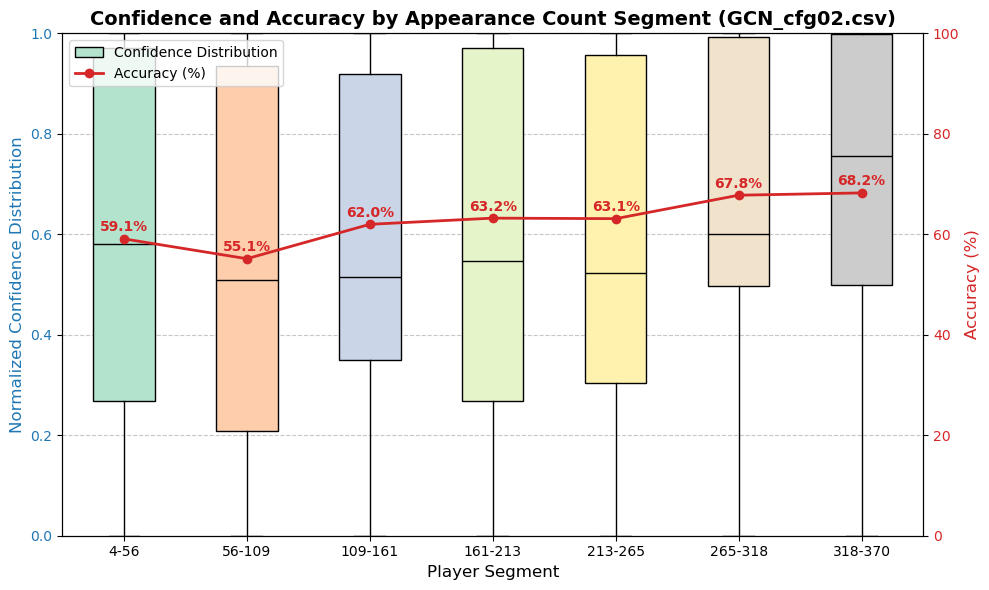

--- Generated Segmentation Dictionary for Appearance Count ---
'4-56': 44 players
'56-109': 38 players
'109-161': 26 players
'161-213': 19 players
'213-265': 14 players
'265-318': 5 players
'318-370': 4 players
Total segments created: 7
Total players segmented: 150
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


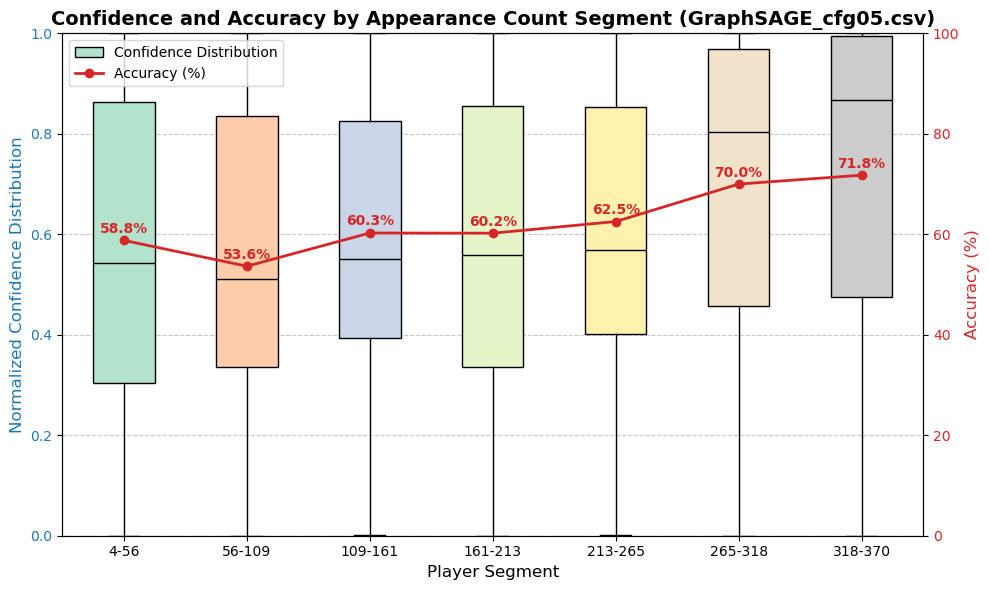

--- Generated Segmentation Dictionary for Appearance Count ---
'4-56': 44 players
'56-109': 38 players
'109-161': 26 players
'161-213': 19 players
'213-265': 14 players
'265-318': 5 players
'318-370': 4 players
Total segments created: 7
Total players segmented: 150
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/3190094617.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


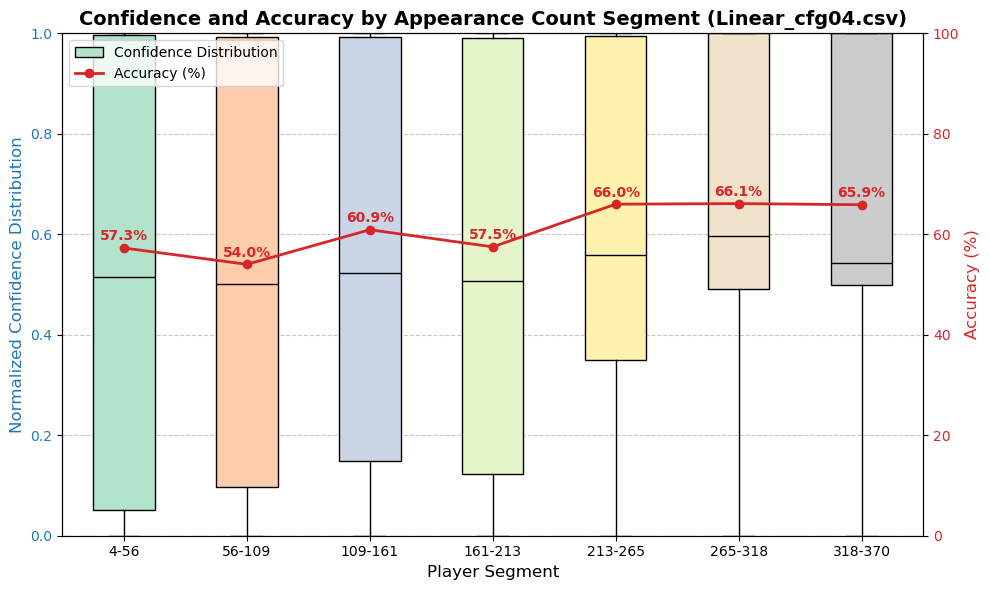

In [13]:
MATCHES_FILEPATH = '../data/processed_matches/raw/edges.csv'
NUM_APPEARANCE_SEGMENTS = 7

def segment_players_by_appearance_count_and_plot(predictions_filename):
    """
    Counts the total appearances for each player in the training set (edges.csv),
    segments the players into 7 equal-width bins based on these counts, 
    and calls the plotting function.

    Args:
        predictions_filename (str): Path to predictions CSV.
    """
    
    # --- 1. Load Data ---
    try:
        # Load match data (training set)
        matches = pd.read_csv(MATCHES_FILEPATH)
    except FileNotFoundError:
        print(f"Error: Match file not found at {MATCHES_FILEPATH}")
        return
        
    try:
        # Load player data to map index to ID
        players_df = pd.read_csv(PLAYERS)
    except FileNotFoundError:
        print(f"Error: Player file not found at {PLAYERS}")
        return

    # --- 2. Calculate Appearance Counts ---
    
    # Create a Series mapping the index position to the actual player_id
    idx_to_id = players_df['player_id']
    
    # 2a. Combine winner and loser indices into a single Series for counting
    # We count every time a player appears as a winner or a loser
    winner_counts = matches['winner_idx'].value_counts()
    loser_counts = matches['loser_idx'].value_counts()
    
    # Sum the counts for all unique indices that appeared in matches
    all_counts = winner_counts.add(loser_counts, fill_value=0).astype(int)
    
    # 2b. Map the index position to the player_id and create a final DataFrame
    player_appearance_df = pd.DataFrame({
        'player_id': all_counts.index.map(idx_to_id.get),
        'appearance_count': all_counts.values
    }).dropna(subset=['player_id']) # Drop any indices that didn't map (shouldn't happen if indices are correct)
    
    player_appearance_df['player_id'] = player_appearance_df['player_id'].astype(int)

    # --- 3. Create Segments (Equal-Width Binning) ---
    
    data_series = player_appearance_df['appearance_count']
    if data_series.empty:
        print("Error: No appearance data found for players.")
        return

    # Calculate bin edges
    min_val = data_series.min()
    max_val = data_series.max()
    
    # Create equal-width bins
    bins = np.linspace(min_val, max_val, NUM_APPEARANCE_SEGMENTS + 1)
    
    # Assign each player to a bin index
    player_appearance_df['bin'] = pd.cut(data_series, 
                                         bins=bins, 
                                         labels=False, 
                                         include_lowest=True, 
                                         right=True)

    # --- 4. Build the Segment Dictionary ---
    segment_dict = {}
    
    for i in range(NUM_APPEARANCE_SEGMENTS):
        # Find players in the current bin
        bin_players = player_appearance_df[player_appearance_df['bin'] == i]
        
        # Create the label for the bin (e.g., "10-50")
        lower_bound = bins[i]
        upper_bound = bins[i+1]
        
        # Format the label to be clean integers
        label = f"{int(round(lower_bound))}-{int(round(upper_bound))}"
        
        # Store the set of player IDs for this segment
        segment_dict[label] = set(bin_players['player_id'].tolist())

    # --- 5. Contextual Information and Plotting ---
    
    plot_title = f"Confidence and Accuracy by Appearance Count Segment ({predictions_filename.split('/')[-1]})"
    
    # Print the resulting segmentation dictionary for inspection
    print(f"--- Generated Segmentation Dictionary for Appearance Count ---")
    total_players = 0
    for label, id_set in segment_dict.items():
        count = len(id_set)
        print(f"'{label}': {count} players")
        total_players += count
    print(f"Total segments created: {len(segment_dict)}")
    print(f"Total players segmented: {total_players}")
    print("---------------------------------------------------------------")

    # --- 6. Call the Plotting Function ---
    plot_segmented_confidence_and_accuracy(
        predictions_filename=predictions_filename,
        plot_title=plot_title,
        segment_dict=segment_dict
    )

for filepath in best_model_files:
    segment_players_by_appearance_count_and_plot(filepath)

In [14]:
def plot_match_segments(predictions_filename, plot_title, segment_dict):
    """
    Displays a box plot and accuracy line based on match-centric segments.
    
    NOTE: The segment_dict keys are the segment labels, and the values are
    sets of match indices (or the DataFrame index) belonging to that segment.

    Args:
        predictions_filename (str): Path to predictions CSV.
        plot_title (str): Title for the box plot.
        segment_dict (dict): Dictionary mapping segment_label (str) to a set 
                             of match indices (int) belonging to that segment.
        players_filepath (str): Path to players CSV (used for context, not calculation).
    """
    # Load predictions data
    preds = pd.read_csv(predictions_filename)

    # --- 1. Confidence Normalization ---
    
    preds['conf_sum'] = preds['pred'] + preds['reverse_pred']
    preds['normalized_confidence'] = np.where(
        preds['conf_sum'] == 0, 
        np.nan, 
        preds['pred'] / preds['conf_sum']
    )
    preds = preds.dropna(subset=['normalized_confidence'])

    # --- 2. Data Preparation ---

    segment_data = {}
    accuracy_data = {}
    segment_labels = list(segment_dict.keys())

    for label in segment_labels:
        # Get the indices for the current segment
        match_indices = list(segment_dict[label])
        
        # Filter the full DataFrame using the indices
        current_segment_df = preds.loc[match_indices].copy()
        
        # 1. Confidence Data (for Box Plot)
        if not current_segment_df.empty:
            segment_data[label] = current_segment_df['normalized_confidence'].tolist()
        else:
            segment_data[label] = []
            
        # 2. Accuracy Data (for Line Plot)
        total_predictions = len(current_segment_df)
        if total_predictions > 0:
            # Accuracy: number of times pred > reverse_pred 
            correct_predictions = (current_segment_df['pred'] > current_segment_df['reverse_pred']).sum()
            accuracy = (correct_predictions / total_predictions) * 100
        else:
            accuracy = 0
            
        accuracy_data[label] = accuracy

    # --- 3. Plotting (Box Plot and Line Plot) ---
    
    # 

    # (Plotting code from your previous function is reused here...)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Box Plot (Normalized Confidence Distribution) ---
    box_data = [segment_data[label] for label in segment_labels]
    
    # Use ax1 for box plot
    bp = ax1.boxplot(box_data, positions=range(len(segment_labels)), 
                      labels=segment_labels, patch_artist=True, 
                      showfliers=False, medianprops={'color': 'black'})
    
    colors = plt.cm.get_cmap('Pastel2', len(segment_labels))
    for patch, color in zip(bp['boxes'], colors(range(len(segment_labels)))):
        patch.set_facecolor(color)

    ax1.set_xlabel('Match Segment', fontsize=12)
    ax1.set_ylabel('Normalized Confidence Distribution', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, 1)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Line Plot (Accuracy) ---
    ax2 = ax1.twinx()
    acc_values = [accuracy_data[label] for label in segment_labels]
    
    # Plot the accuracy line on ax2
    line, = ax2.plot(range(len(segment_labels)), acc_values, 
                     color='tab:red', marker='o', linestyle='-', linewidth=2, 
                     label='Accuracy (%)')
    
    # Add accuracy labels
    for i, acc in enumerate(acc_values):
        ax2.text(i, acc + 1.5, f'{acc:.1f}%', ha='center', color='tab:red', fontweight='bold')
    
    ax2.set_ylabel('Accuracy (%)', color='tab:red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_ylim(0, 100)
    
    # Final Formatting
    ax1.set_title(plot_title, fontsize=14, fontweight='bold')
    ax1.legend([bp['boxes'][0], line], ['Confidence Distribution', 'Accuracy (%)'], loc='upper left')
    
    plt.tight_layout()
    plt.show()
    return fig

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


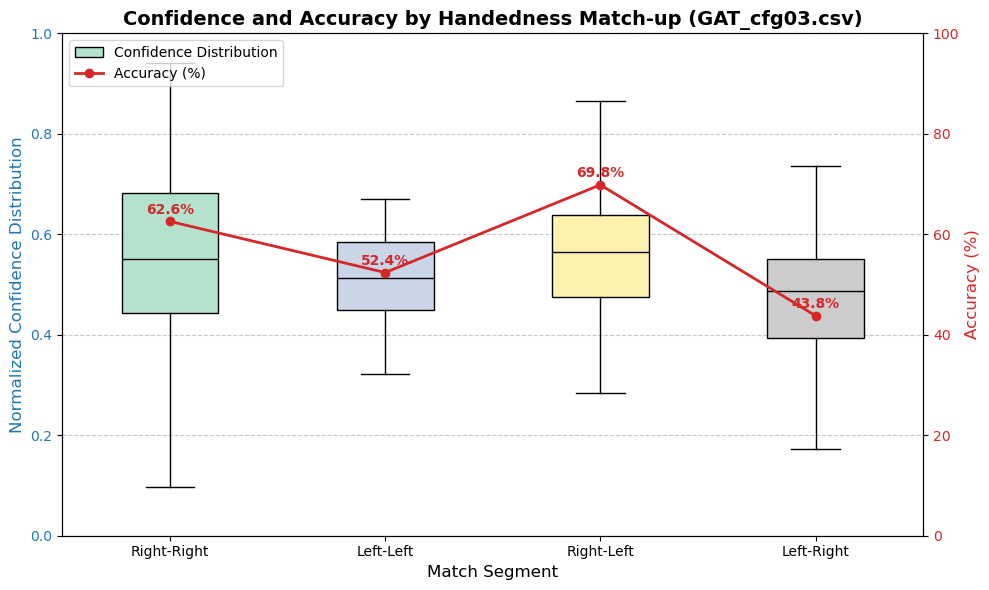

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


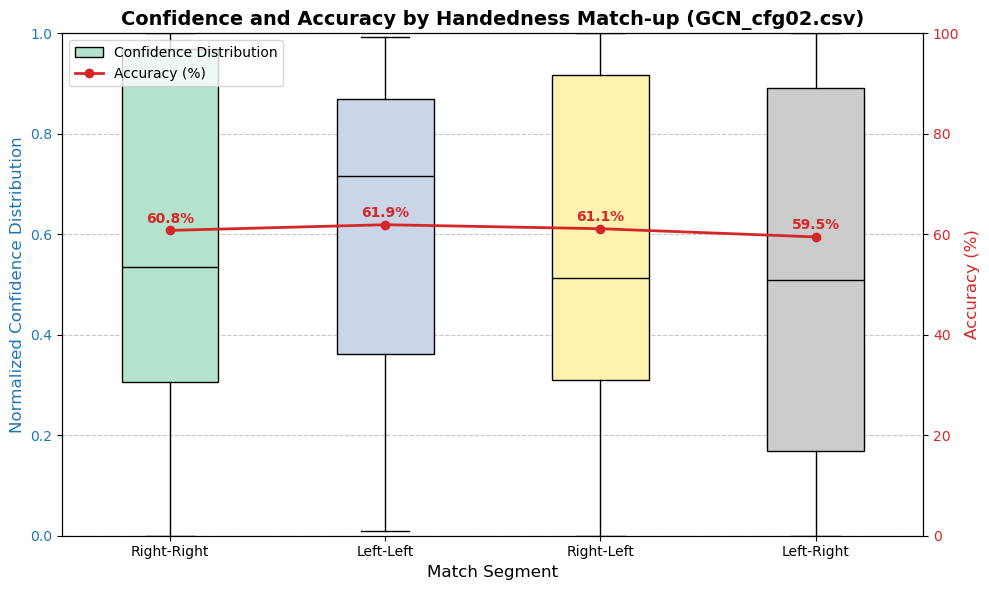

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


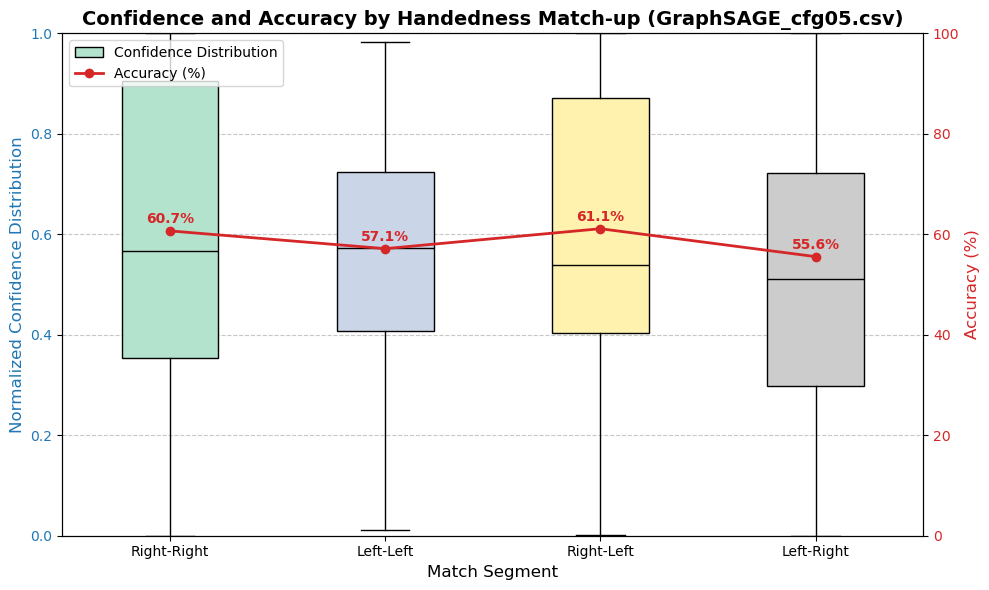

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


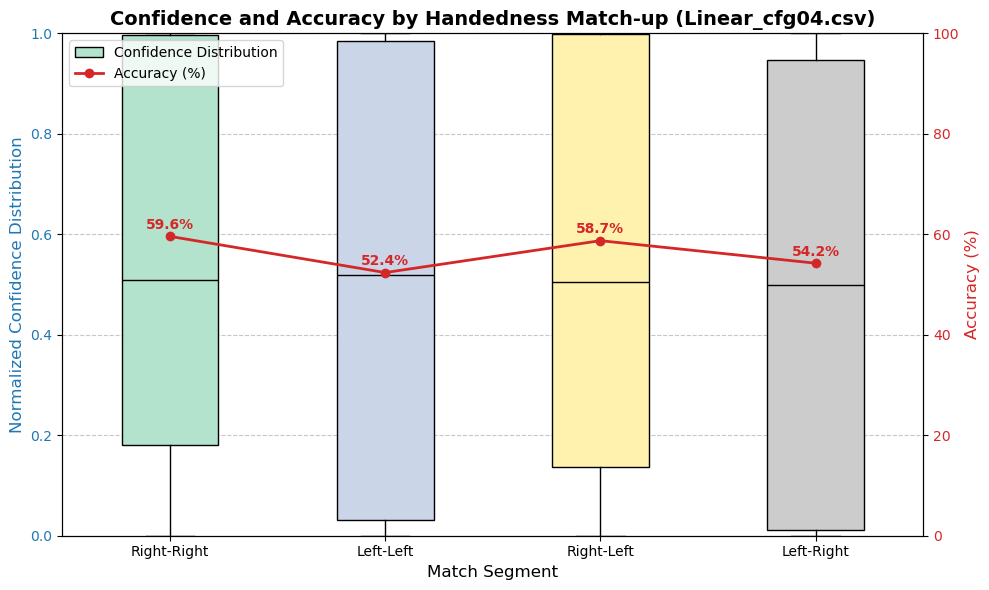

In [15]:
def segment_by_handedness_combo(predictions_df, players_filepath):
    """
    Segments matches based on the handedness combination of P1 and P2.

    Args:
        predictions_df (pd.DataFrame): The raw predictions data (must have p1_id, p2_id).
        players_filepath (str): Path to the players CSV (to get the 'hand' feature).

    Returns:
        dict: {segment_label: set_of_match_indices}
    """
    players = pd.read_csv(players_filepath)
    # Map player_id to 'hand' (0=Right, 1=Left)
    hand_map = dict(zip(players['player_id'], players['hand']))
    
    df = predictions_df.copy()
    
    # Map handedness to match data
    df['p1_hand'] = df['p1_id'].map(hand_map)
    df['p2_hand'] = df['p2_id'].map(hand_map)
    
    # Drop rows where handedness data is missing or invalid (not 0 or 1)
    df = df[df['p1_hand'].isin([0, 1]) & df['p2_hand'].isin([0, 1])]
    
    segment_dict = {}
    
    # R vs R (0 vs 0)
    rr_mask = (df['p1_hand'] == 0) & (df['p2_hand'] == 0)
    segment_dict['Right-Right'] = set(df[rr_mask].index)
    
    # L vs L (1 vs 1)
    ll_mask = (df['p1_hand'] == 1) & (df['p2_hand'] == 1)
    segment_dict['Left-Left'] = set(df[ll_mask].index)
    
    # R vs L (0 vs 1)
    rl_mask = (df['p1_hand'] == 0) & (df['p2_hand'] == 1)
    segment_dict['Right-Left'] = set(df[rl_mask].index)
    
    # L vs R (1 vs 0)
    lr_mask = (df['p1_hand'] == 1) & (df['p2_hand'] == 0)
    segment_dict['Left-Right'] = set(df[lr_mask].index)
    
    # Note: If you want to combine RL and LR into 'Different Handedness',
    # you would union the two sets here. For now, we keep them separate.
    
    return segment_dict

for filepath in best_model_files:
    hand_segments = segment_by_handedness_combo(pd.read_csv(filepath), PLAYERS)
    plot_match_segments(
        predictions_filename=filepath,
        plot_title=f"Confidence and Accuracy by Handedness Match-up ({filepath.split('/')[-1]})",
        segment_dict=hand_segments
    )

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


--- Generated Segmentation Dictionary for Rank Difference (P2 - P1, 7 bins) ---
'-99 to -70': 13 matches
'-70 to -42': 60 matches
'-42 to -13': 230 matches
'-13 to +16': 434 matches
'+16 to +45': 385 matches
'+45 to +73': 154 matches
'+73 to +102': 31 matches
---------------------------------------------------------------


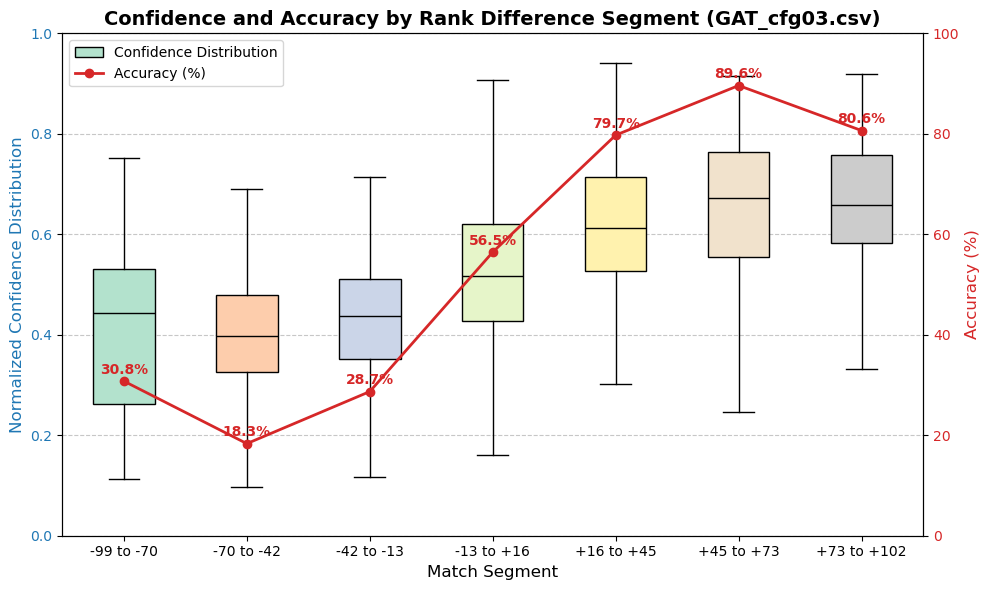

/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


--- Generated Segmentation Dictionary for Rank Difference (P2 - P1, 7 bins) ---
'-99 to -70': 13 matches
'-70 to -42': 60 matches
'-42 to -13': 230 matches
'-13 to +16': 434 matches
'+16 to +45': 385 matches
'+45 to +73': 154 matches
'+73 to +102': 31 matches
---------------------------------------------------------------


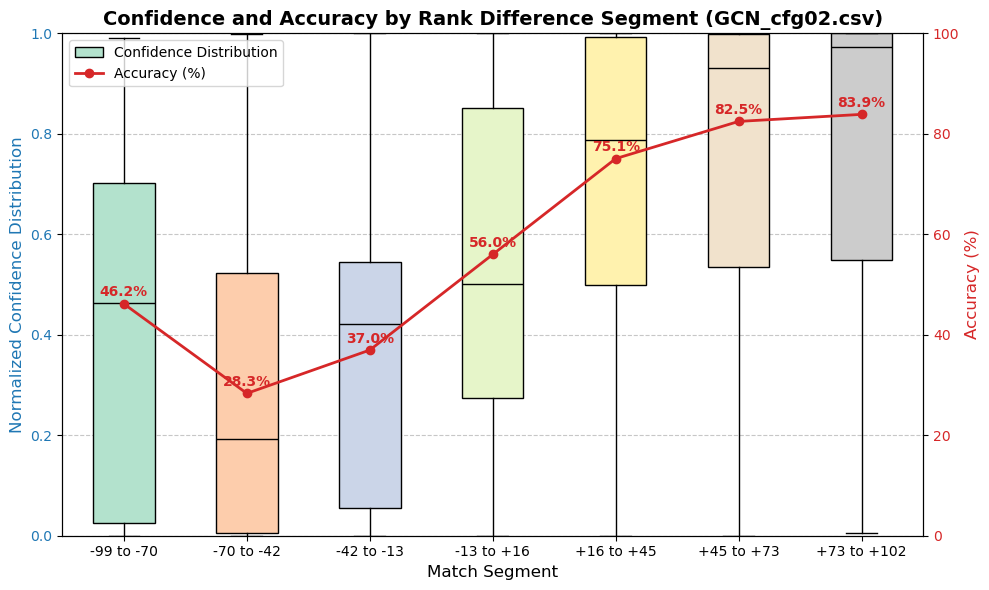

--- Generated Segmentation Dictionary for Rank Difference (P2 - P1, 7 bins) ---
'-99 to -70': 13 matches
'-70 to -42': 60 matches
'-42 to -13': 230 matches
'-13 to +16': 434 matches
'+16 to +45': 385 matches
'+45 to +73': 154 matches
'+73 to +102': 31 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


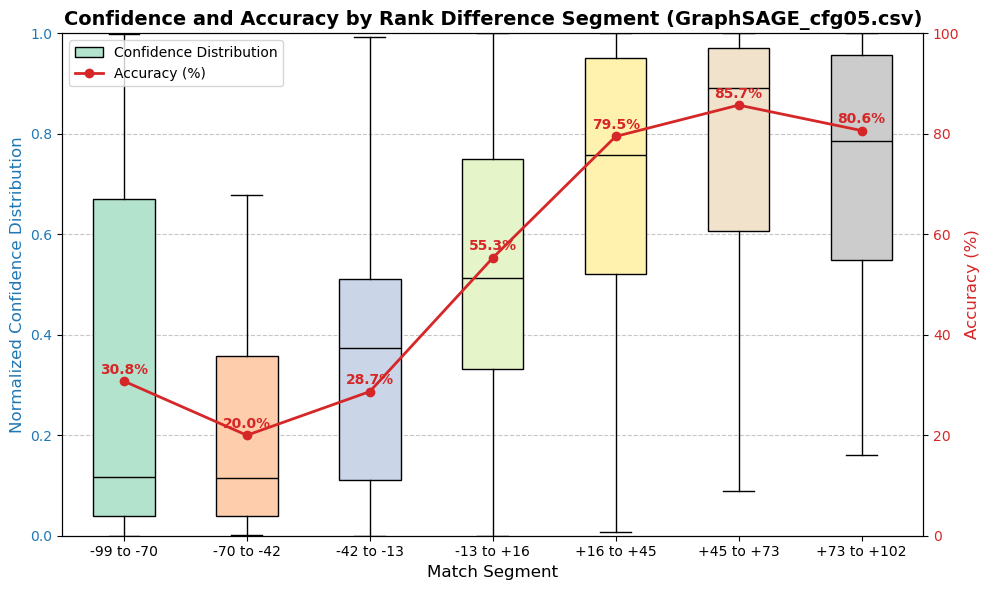

--- Generated Segmentation Dictionary for Rank Difference (P2 - P1, 7 bins) ---
'-99 to -70': 13 matches
'-70 to -42': 60 matches
'-42 to -13': 230 matches
'-13 to +16': 434 matches
'+16 to +45': 385 matches
'+45 to +73': 154 matches
'+73 to +102': 31 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


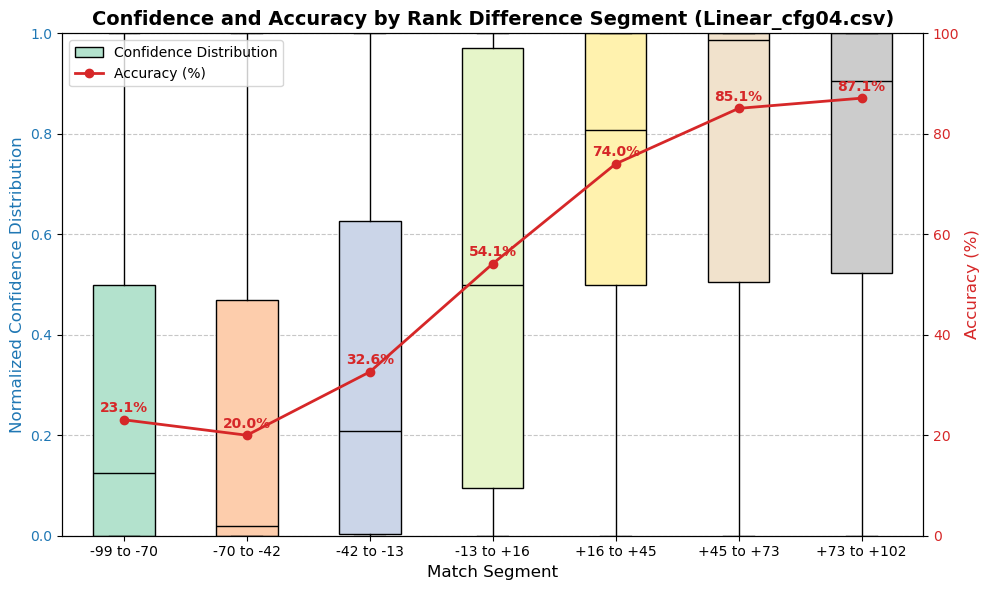

In [16]:
NUM_RANK_SEGMENTS = 7

def segment_by_rank_difference(predictions_df, players_filepath):
    """
    Segments matches into 7 equal-width bins based on the rank difference 
    (P2_rank - P1_rank).

    Args:
        predictions_df (pd.DataFrame): The raw predictions data (must have p1_id, p2_id).
        players_filepath (str): Path to the players CSV (to get the 'current_rank' feature).

    Returns:
        dict: {segment_label: set_of_match_indices}
    """
    try:
        players = pd.read_csv(players_filepath)
    except FileNotFoundError:
        print(f"Error: Player file not found at {players_filepath}")
        return {}

    # Map player_id to 'current_rank'
    rank_map = dict(zip(players['player_id'], players['current_rank']))
    
    df = predictions_df.copy()
    
    # 1. Map Ranks and Calculate Difference
    df['p1_rank'] = df['p1_id'].map(rank_map)
    df['p2_rank'] = df['p2_id'].map(rank_map)
    
    # Calculate rank difference: P2_rank - P1_rank
    # Positive difference means P1 is the better player (P1_rank < P2_rank)
    # Negative difference means P2 is the better player (P2_rank < P1_rank)
    df['rank_diff'] = df['p2_rank'] - df['p1_rank']
    
    # Drop matches where rank data is missing for either player
    df = df.dropna(subset=['rank_diff'])
    
    if df.empty:
        print("Warning: No matches remaining after rank filtering.")
        return {}

    # 2. Create Segments (Equal-Width Binning)
    data_series = df['rank_diff']
    
    # Calculate bin edges
    min_val = data_series.min()
    max_val = data_series.max()
    
    # Create equal-width bins (NUM_RANK_SEGMENTS + 1 edges for N segments)
    bins = np.linspace(min_val, max_val, NUM_RANK_SEGMENTS + 1)
    
    # Assign each match to a bin index
    df['bin'] = pd.cut(data_series, 
                       bins=bins, 
                       labels=False, 
                       include_lowest=True, 
                       right=True)

    # 3. Build the Segment Dictionary
    segment_dict = {}
    
    for i in range(NUM_RANK_SEGMENTS):
        bin_matches = df[df['bin'] == i]
        
        # Create the label for the bin (e.g., "-50 to 0")
        lower_bound = bins[i]
        upper_bound = bins[i+1]
        
        # Format the label to be clean integers
        label = f"{int(round(lower_bound)):+g} to {int(round(upper_bound)):+g}"
        
        # Store the set of match indices (DataFrame index) for this segment
        segment_dict[label] = set(bin_matches.index)
        
    # --- 4. Print and Return ---
    
    print(f"--- Generated Segmentation Dictionary for Rank Difference (P2 - P1, {NUM_RANK_SEGMENTS} bins) ---")
    for label, indices in segment_dict.items():
        print(f"'{label}': {len(indices)} matches")
    print("---------------------------------------------------------------")
    
    return segment_dict

for filepath in best_model_files:
    rank_diff_segments = segment_by_rank_difference(pd.read_csv(filepath), PLAYERS)
    plot_match_segments(
        predictions_filename=filepath,
        plot_title=f"Confidence and Accuracy by Rank Difference Segment ({filepath.split('/')[-1]})",
        segment_dict=rank_diff_segments
    )

--- Generated Segmentation Dictionary for Height Difference (P2 - P1, 7 bins) ---
'-26cm to -18cm': 9 matches
'-18cm to -11cm': 96 matches
'-11cm to -3cm': 337 matches
'-3cm to +5cm': 375 matches
'+5cm to +13cm': 344 matches
'+13cm to +20cm': 128 matches
'+20cm to +28cm': 18 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


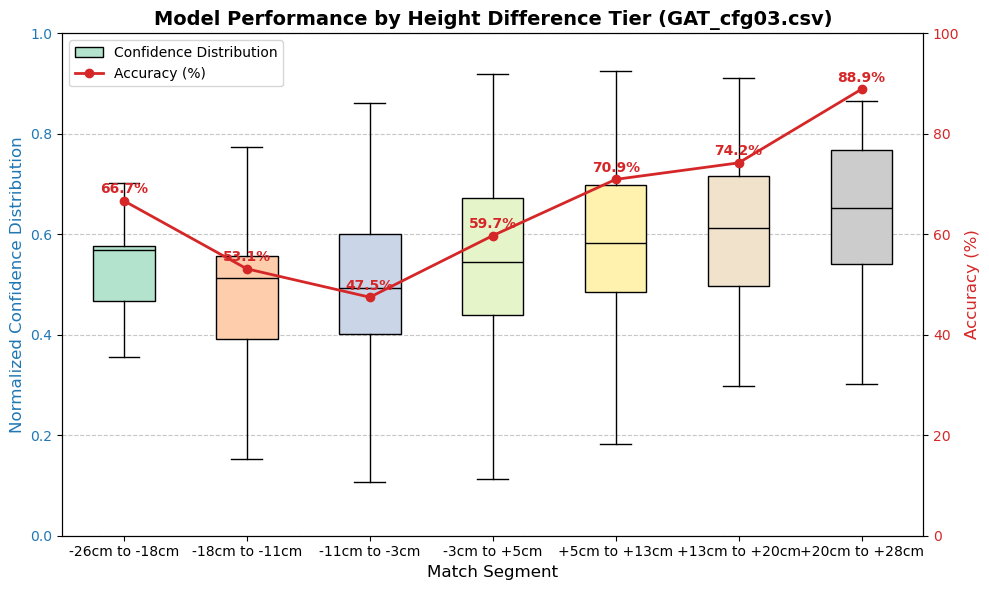

--- Generated Segmentation Dictionary for Height Difference (P2 - P1, 7 bins) ---
'-26cm to -18cm': 9 matches
'-18cm to -11cm': 96 matches
'-11cm to -3cm': 337 matches
'-3cm to +5cm': 375 matches
'+5cm to +13cm': 344 matches
'+13cm to +20cm': 128 matches
'+20cm to +28cm': 18 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


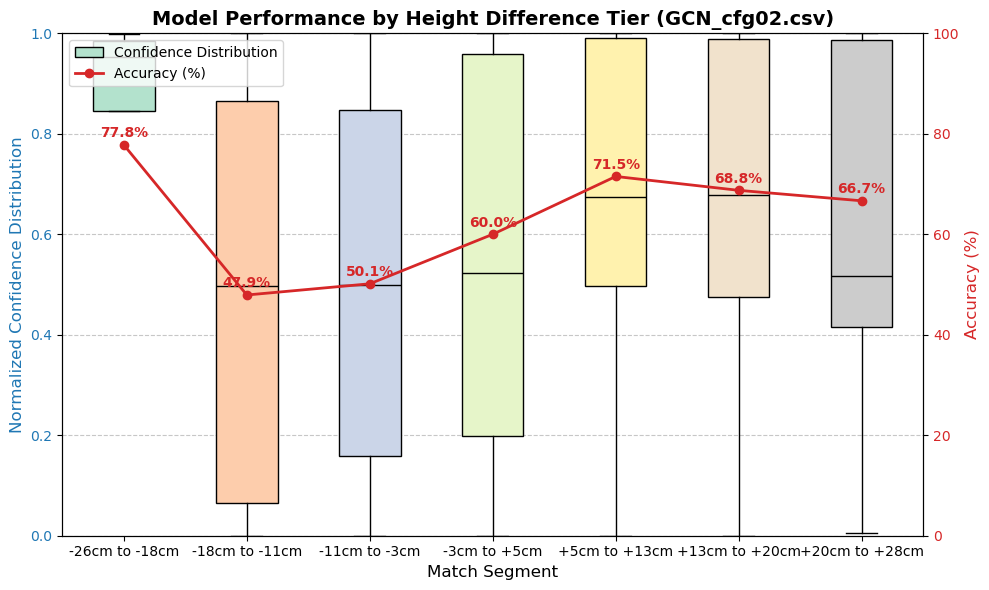

--- Generated Segmentation Dictionary for Height Difference (P2 - P1, 7 bins) ---
'-26cm to -18cm': 9 matches
'-18cm to -11cm': 96 matches
'-11cm to -3cm': 337 matches
'-3cm to +5cm': 375 matches
'+5cm to +13cm': 344 matches
'+13cm to +20cm': 128 matches
'+20cm to +28cm': 18 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


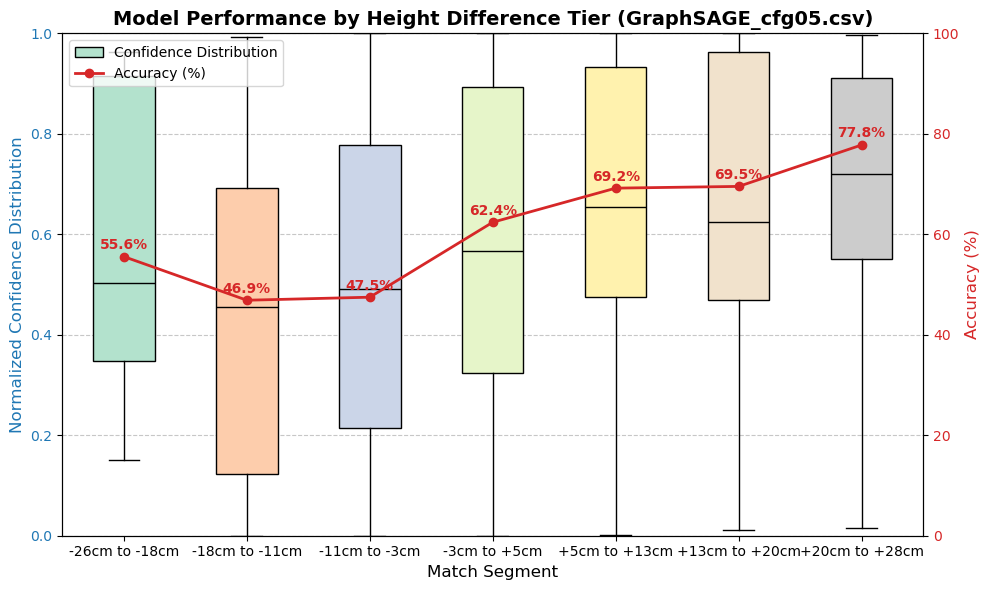

--- Generated Segmentation Dictionary for Height Difference (P2 - P1, 7 bins) ---
'-26cm to -18cm': 9 matches
'-18cm to -11cm': 96 matches
'-11cm to -3cm': 337 matches
'-3cm to +5cm': 375 matches
'+5cm to +13cm': 344 matches
'+13cm to +20cm': 128 matches
'+20cm to +28cm': 18 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


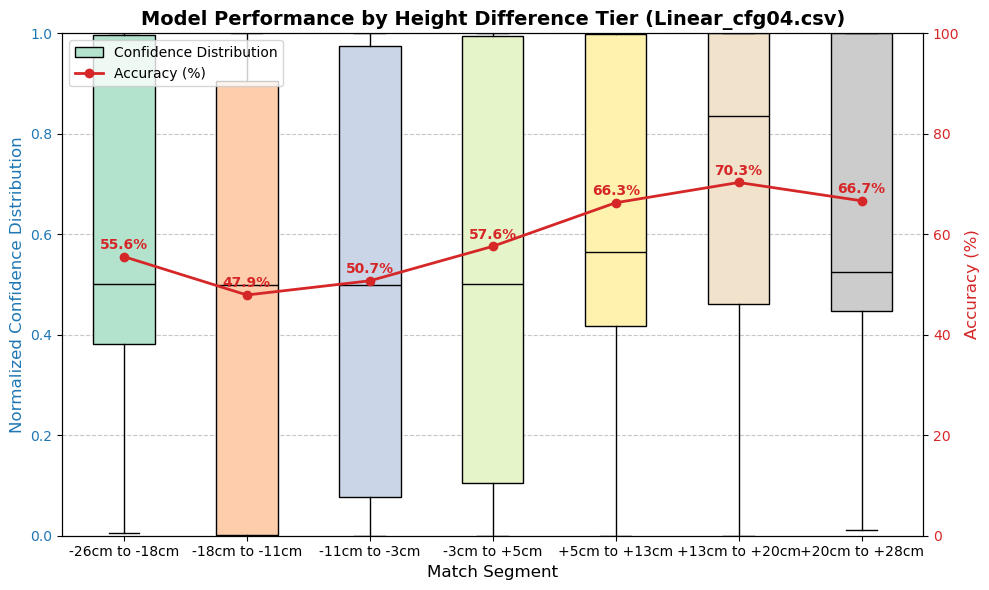

In [23]:
NUM_HEIGHT_SEGMENTS = 7

def segment_by_height_difference(predictions_df, players_filepath):
    """
    Segments matches into 7 equal-width bins based on the height difference 
    (P2_height - P1_height).

    Args:
        predictions_df (pd.DataFrame): The raw predictions data (must have p1_id, p2_id).
        players_filepath (str): Path to the players CSV (to get the 'height' feature).

    Returns:
        dict: {segment_label: set_of_match_indices}
    """
    try:
        players = pd.read_csv(players_filepath)
    except FileNotFoundError:
        print(f"Error: Player file not found at {players_filepath}")
        return {}

    # Map player_id to 'height'
    height_map = dict(zip(players['player_id'], players['height']))
    
    df = predictions_df.copy()
    
    # 1. Map Heights and Calculate Difference
    df['p1_height'] = df['p1_id'].map(height_map)
    df['p2_height'] = df['p2_id'].map(height_map)
    
    # Calculate height difference: P2_height - P1_height
    # Positive difference means P1 is taller
    # Negative difference means P2 is taller
    df['height_diff'] = df['p1_height'] - df['p2_height']
    
    # Drop matches where height data is missing for either player
    df = df.dropna(subset=['height_diff'])
    
    if df.empty:
        print("Warning: No matches remaining after height filtering.")
        return {}

    # 2. Create Segments (Equal-Width Binning)
    data_series = df['height_diff']
    
    # Calculate bin edges
    min_val = data_series.min()
    max_val = data_series.max()
    
    # Create equal-width bins (NUM_HEIGHT_SEGMENTS + 1 edges for N segments)
    bins = np.linspace(min_val, max_val, NUM_HEIGHT_SEGMENTS + 1)
    
    # Assign each match to a bin index
    df['bin'] = pd.cut(data_series, 
                       bins=bins, 
                       labels=False, 
                       include_lowest=True, 
                       right=True)

    # 3. Build the Segment Dictionary
    segment_dict = {}
    
    for i in range(NUM_HEIGHT_SEGMENTS):
        bin_matches = df[df['bin'] == i]
        
        # Create the label for the bin (e.g., "-10cm to 0cm")
        lower_bound = bins[i]
        upper_bound = bins[i+1]
        
        # Format the label to be clean integers (using 'cm' for clarity)
        label = f"{int(round(lower_bound)):+g}cm to {int(round(upper_bound)):+g}cm"
        
        # Store the set of match indices (DataFrame index) for this segment
        segment_dict[label] = set(bin_matches.index)
        
    # --- 4. Print and Return ---
    
    print(f"--- Generated Segmentation Dictionary for Height Difference (P2 - P1, {NUM_HEIGHT_SEGMENTS} bins) ---")
    for label, indices in segment_dict.items():
        print(f"'{label}': {len(indices)} matches")
    print("---------------------------------------------------------------")
    
    return segment_dict

# --- Example of how to run the analysis ---

for predictions_filename in best_model_files:
    raw_preds = pd.read_csv(predictions_filename)

    # 1. Generate the segments
    height_segments = segment_by_height_difference(raw_preds, PLAYERS)

    # 2. Call the generic plotting function
    plot_match_segments(
        predictions_filename=predictions_filename,
        plot_title=f'Model Performance by Height Difference Tier ({predictions_filename.split("/")[-1]})',
        segment_dict=height_segments
    )


--- Generated Segmentation Dictionary for Age Difference (P2 - P1, 7 bins) ---
'-19 to -14': 23 matches
'-14 to -8': 87 matches
'-8 to -3': 269 matches
'-3 to +2': 526 matches
'+2 to +7': 276 matches
'+7 to +13': 93 matches
'+13 to +18': 33 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


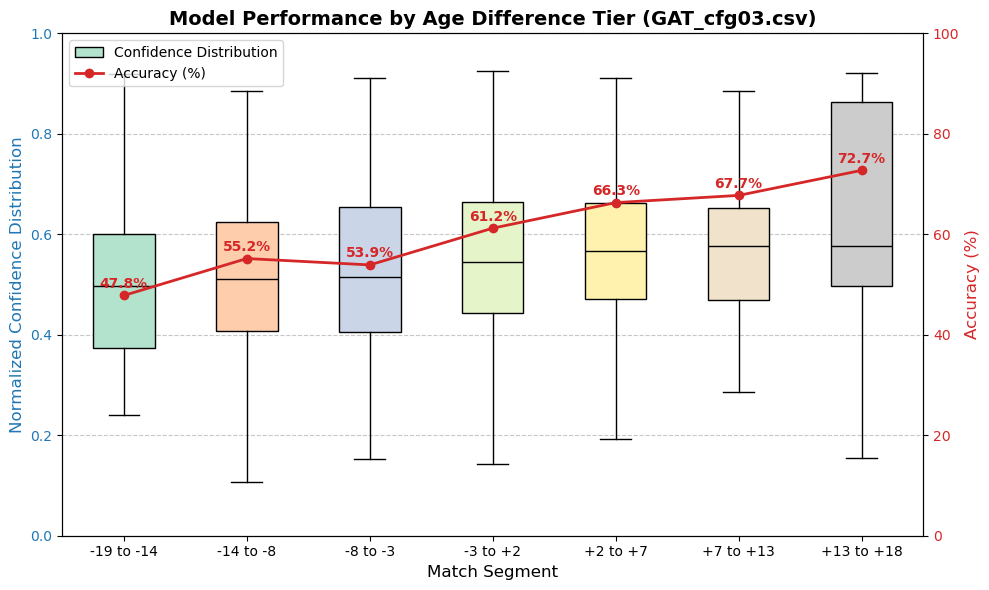

--- Generated Segmentation Dictionary for Age Difference (P2 - P1, 7 bins) ---
'-19 to -14': 23 matches
'-14 to -8': 87 matches
'-8 to -3': 269 matches
'-3 to +2': 526 matches
'+2 to +7': 276 matches
'+7 to +13': 93 matches
'+13 to +18': 33 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


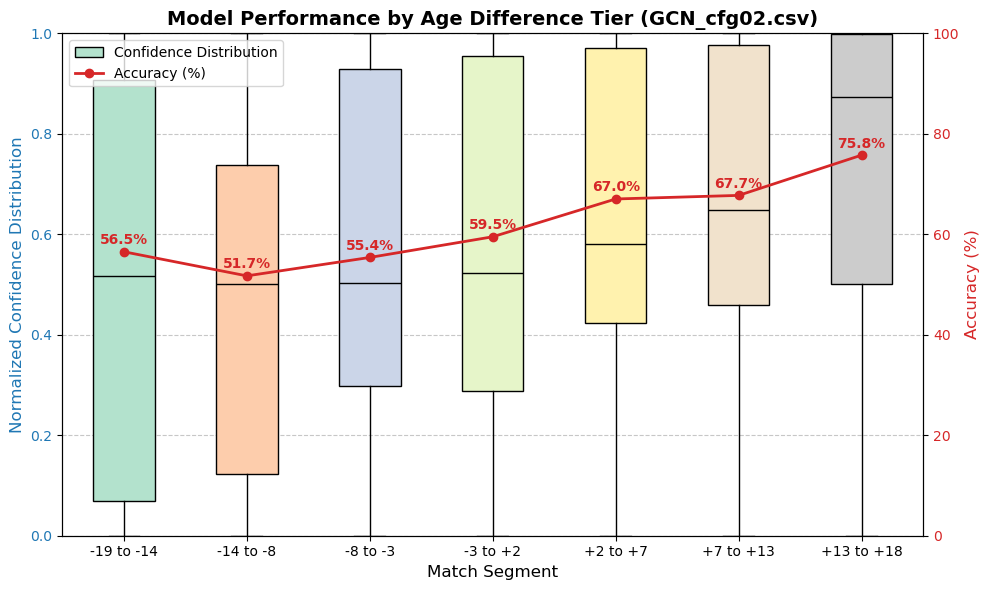

--- Generated Segmentation Dictionary for Age Difference (P2 - P1, 7 bins) ---
'-19 to -14': 23 matches
'-14 to -8': 87 matches
'-8 to -3': 269 matches
'-3 to +2': 526 matches
'+2 to +7': 276 matches
'+7 to +13': 93 matches
'+13 to +18': 33 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


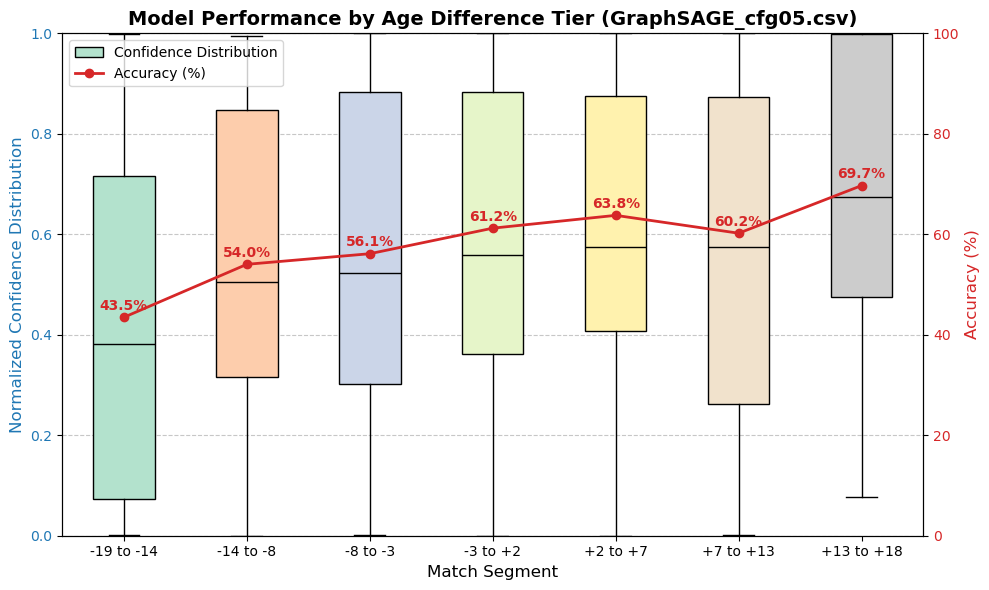

--- Generated Segmentation Dictionary for Age Difference (P2 - P1, 7 bins) ---
'-19 to -14': 23 matches
'-14 to -8': 87 matches
'-8 to -3': 269 matches
'-3 to +2': 526 matches
'+2 to +7': 276 matches
'+7 to +13': 93 matches
'+13 to +18': 33 matches
---------------------------------------------------------------


/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, positions=range(len(segment_labels)),
/var/folders/06/1l5jck8n68dfvl5r4vc50dxc0000gn/T/ipykernel_1159/71139703.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(segment_labels))


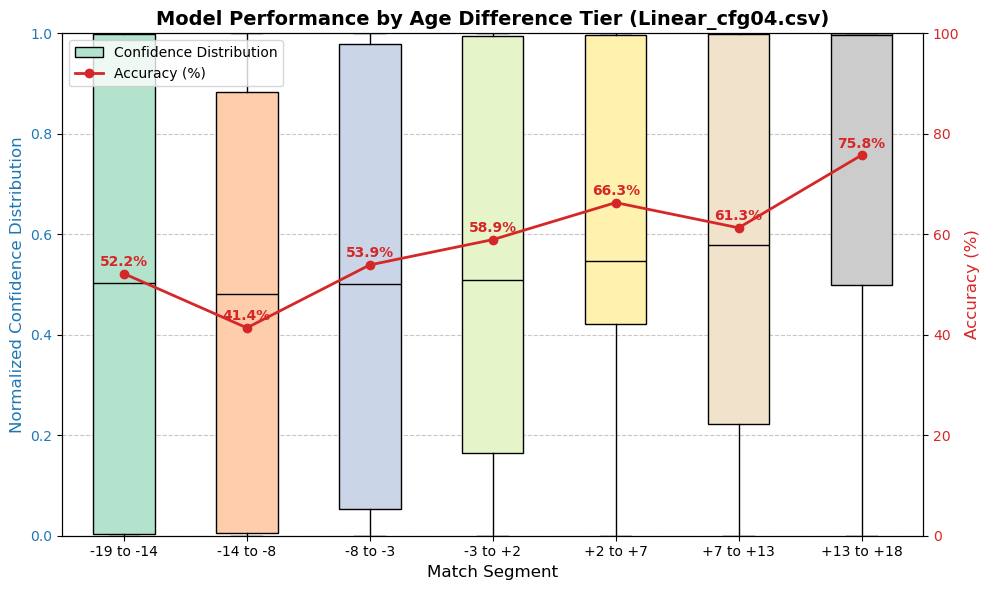

In [24]:
NUM_AGE_SEGMENTS = 7

def calculate_age_from_dob(dob_series):
    """
    Converts DOB in YYYYMMDD.0 format to age in years.
    """
    # 1. Convert the float (YYYYMMDD.0) to an integer string (YYYYMMDD)
    dob_str = dob_series.apply(
        lambda x: str(int(x)) if pd.notna(x) and x == x else np.nan
    ).str.split('.').str[0]
    
    # 2. Convert the YYYYMMDD string to a datetime object
    birth_date = pd.to_datetime(dob_str, format='%Y%m%d', errors='coerce')
    
    today = dt.datetime.now().date()
    
    # Calculate age in years
    def get_age(born):
        if pd.isna(born):
            return np.nan
        # Ensure 'born' is a date object for comparison
        born_date = born.date() if isinstance(born, dt.datetime) else born
        return today.year - born_date.year - ((today.month, today.day) < (born_date.month, born_date.day))

    return birth_date.apply(get_age)


def segment_by_age_difference(predictions_df, players_filepath):
    """
    Segments matches into 7 equal-width bins based on the age difference 
    (P2_age - P1_age).

    Args:
        predictions_df (pd.DataFrame): The raw predictions data (must have p1_id, p2_id).
        players_filepath (str): Path to the players CSV (to get the 'dob' feature).

    Returns:
        dict: {segment_label: set_of_match_indices}
    """
    try:
        players = pd.read_csv(players_filepath)
    except FileNotFoundError:
        print(f"Error: Player file not found at {players_filepath}")
        return {}

    # Calculate ages for all players
    players['age'] = calculate_age_from_dob(players['dob'])

    # Map player_id to 'age'
    age_map = dict(zip(players['player_id'], players['age']))
    
    df = predictions_df.copy()
    
    # 1. Map Ages and Calculate Difference
    df['p1_age'] = df['p1_id'].map(age_map)
    df['p2_age'] = df['p2_id'].map(age_map)
    
    # Calculate age difference: P2_age - P1_age
    # Positive difference means P1 is younger
    # Negative difference means P2 is younger
    df['age_diff'] = df['p1_age'] - df['p2_age']
    
    # Drop matches where age data is missing for either player
    df = df.dropna(subset=['age_diff'])
    
    if df.empty:
        print("Warning: No matches remaining after age filtering.")
        return {}

    # 2. Create Segments (Equal-Width Binning)
    data_series = df['age_diff']
    
    # Calculate bin edges
    min_val = data_series.min()
    max_val = data_series.max()
    
    # Create equal-width bins (NUM_AGE_SEGMENTS + 1 edges for N segments)
    bins = np.linspace(min_val, max_val, NUM_AGE_SEGMENTS + 1)
    
    # Assign each match to a bin index
    df['bin'] = pd.cut(data_series, 
                       bins=bins, 
                       labels=False, 
                       include_lowest=True, 
                       right=True)

    # 3. Build the Segment Dictionary
    segment_dict = {}
    
    for i in range(NUM_AGE_SEGMENTS):
        bin_matches = df[df['bin'] == i]
        
        # Create the label for the bin (e.g., "-2 years to 0 years")
        lower_bound = bins[i]
        upper_bound = bins[i+1]
        
        # Format the label, using 'years' for clarity
        label = f"{int(round(lower_bound)):+g} to {int(round(upper_bound)):+g}"
        
        # Store the set of match indices (DataFrame index) for this segment
        segment_dict[label] = set(bin_matches.index)
        
    # --- 4. Print and Return ---
    
    print(f"--- Generated Segmentation Dictionary for Age Difference (P2 - P1, {NUM_AGE_SEGMENTS} bins) ---")
    for label, indices in segment_dict.items():
        print(f"'{label}': {len(indices)} matches")
    print("---------------------------------------------------------------")
    
    return segment_dict

# --- Example of how to run the analysis ---

for predictions_filename in best_model_files:
    raw_preds = pd.read_csv(predictions_filename)

    # 1. Generate the segments
    age_segments = segment_by_age_difference(raw_preds, PLAYERS)

    # 2. Call the generic plotting function
    plot_match_segments(
        predictions_filename=predictions_filename,
        plot_title=f'Model Performance by Age Difference Tier ({predictions_filename.split("/")[-1]})',
        segment_dict=age_segments
    )

In [20]:
MATCHES_FILEPATH = '../data/processed_matches/raw/edges.csv'  # Path to matches CSV

def calculate_rank_benchmark_accuracy():
    """
    Calculates the percentage of matches in the edges.csv where the winner 
    had a better (lower number) current_rank than the loser, excluding ties.
    
    Returns:
        float: The benchmark accuracy percentage (0 to 100).
    """
    
    # --- 1. Load Data ---
    try:
        # Load match data
        matches = pd.read_csv(MATCHES_FILEPATH)

        # Get only test maches
        matches = matches[matches['split'] == 'test'].reset_index(drop=True)
    except FileNotFoundError:
        print(f"Error: Match file not found at {MATCHES_FILEPATH}")
        return 0.0
        
    try:
        # Load player data to get ranks
        players_df = pd.read_csv(PLAYERS)
    except FileNotFoundError:
        print(f"Error: Player file not found at {PLAYERS}")
        return 0.0

    # --- 2. Create Rank Mapping ---
    
    # Ensure the players DataFrame is correctly indexed (0 to N-1)
    players_df = players_df.reset_index(drop=True)
    
    # Map the indices to their ranks
    rank_series = players_df['current_rank']
    
    # --- 3. Extract Ranks for Winners and Losers ---
    
    try:
        # Get ranks using index mapping
        winner_ranks = matches['winner_idx'].apply(lambda x: rank_series.loc[x])
        loser_ranks = matches['loser_idx'].apply(lambda x: rank_series.loc[x])
    except KeyError:
        print("Error: Player index in edges.csv is out of range for players.csv.")
        return 0.0
    
    # Create a DataFrame for easy handling
    rank_comparison_df = pd.DataFrame({
        'winner_rank': winner_ranks,
        'loser_rank': loser_ranks
    }).dropna() # Drop rows if rank was missing for winner or loser

    # --- 4. Calculate Benchmark (Excluding Ties) ---
    
    # Identify ties where ranks are equal
    ties = (rank_comparison_df['winner_rank'] == rank_comparison_df['loser_rank'])
    
    # Filter the DataFrame to exclude ties
    non_tied_matches_df = rank_comparison_df[~ties]
    
    # Total matches where a rank difference exists
    total_non_tied_matches = len(non_tied_matches_df)
    
    if total_non_tied_matches == 0:
        print("Warning: Zero non-tied matches found for analysis.")
        return 0.0
    
    # Count how many times the winner's rank is better/lower (Assumption: Lower is better)
    correct_predictions = (non_tied_matches_df['winner_rank'] < non_tied_matches_df['loser_rank']).sum()
    
    # Convert count to percentage
    benchmark_accuracy = (correct_predictions / total_non_tied_matches) * 100
    
    # --- 5. Output ---
    
    print(f"Total Matches in CSV: {len(matches)}")
    print(f"Total Matches Excluded (Ranks Tied or Missing): {len(matches) - total_non_tied_matches}")
    print(f"Total Matches Analyzed (Non-Tied): {total_non_tied_matches}")
    print("--------------------------------------------------")
    
    return benchmark_accuracy

# --- Example Execution (for context only) ---
rank_benchmark = calculate_rank_benchmark_accuracy()
print(f"Rank-Based Predictor Accuracy (Benchmark): {rank_benchmark:.2f}%")

Total Matches in CSV: 1307
Total Matches Excluded (Ranks Tied or Missing): 12
Total Matches Analyzed (Non-Tied): 1295
--------------------------------------------------
Rank-Based Predictor Accuracy (Benchmark): 64.25%
